In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
nf1 = pd.read_excel('../datasets/dataset-uci.xlsx')

In [3]:
nf1.head

<bound method NDFrame.head of      Unnamed: 0  Case Type  Tumour Case  Age of Mother  Age of Father  \
0             1          0            1           30.0           31.0   
1             2          0            1           22.0           29.0   
2             3          1            1           28.0           26.0   
3             4          0            1           30.0           34.0   
4             5          0            1           27.0           34.0   
..          ...        ...          ...            ...            ...   
291         292          0            1           39.0           45.0   
292         293          0            0           34.0           34.0   
293         294          0            1            NaN            NaN   
294         295          0            0           32.0           40.0   
295         296          0            1           36.0           36.0   

     Age at First Diagnosis  Café au lait (CLS)  Axillary Freckles  \
0                      

In [4]:
nf1.to_csv('../datasets/cleaned_dataset-uci.csv', index=False)

In [5]:
# Class Labels

# - Tumour Case: 0 (Without Tumours), 1 (With Tumours)      <- LABEL
# - Case type: 0 (Sporadic Case), 1 (Familial case)        someone in the family has NF1? 
# - Café au lait (CLS): 0 (Absent),1 (Present)
# - Axillary Freckles: 0 (Absent), 1 (Present) 
# - Inguinal Freckles: 0 (Absent), 1 (Present) 
# - Lisch Nodules: 0 (Absent), 1 (Present) 
# - Dermal Neurofibromins: 0 (Absent), 1 (Present) 
# - Plexiform Neurofibromins: 0 (Absent), 1 (Present) 
# - Optic Glioma: 0 (Absent), 1 (Present) 
# - Skeletal Dysplasia: 0 (Absent), 1 (Present) 
# - Learning Disability: 0 (Absent), 1 (Present) 
# - Hypertension: 0 (Absent), 1 (Present) 
# - Astrocytoma: 0 (Absent), 1 (Present) 
# - Hamartoma: 0 (Absent), 1 (Present) 
# - Scoliosis: 0 (Absent), 1 (Present) 
# - Other Symptoms: 0 (Absent), 1 (at least one of these present: Epilepsy, Rhabdomyoma, Ganglioblastoma, MPNST, Leukaemia, Noonan/Watson/Myelodysplastic Syndrome, Cranial/Brain stem tumour)

In [6]:
nf1.columns

Index(['Unnamed: 0', 'Case Type', 'Tumour Case', 'Age of Mother',
       'Age of Father', 'Age at First Diagnosis', 'Café au lait (CLS)',
       'Axillary Freckles', 'Inguinal Freckles', 'Lisch Nodules',
       'Dermal Neurofibromins', 'Plexiform Neurofibromins', 'Optic Glioma',
       'Skeletal Dysplasia', 'Learning Disability', 'Hypertension',
       'Astrocytoma', 'Hamartoma', 'Scoliosis', 'Other Symptoms'],
      dtype='str')

In [7]:
nf1.hist

<bound method hist_frame of      Unnamed: 0  Case Type  Tumour Case  Age of Mother  Age of Father  \
0             1          0            1           30.0           31.0   
1             2          0            1           22.0           29.0   
2             3          1            1           28.0           26.0   
3             4          0            1           30.0           34.0   
4             5          0            1           27.0           34.0   
..          ...        ...          ...            ...            ...   
291         292          0            1           39.0           45.0   
292         293          0            0           34.0           34.0   
293         294          0            1            NaN            NaN   
294         295          0            0           32.0           40.0   
295         296          0            1           36.0           36.0   

     Age at First Diagnosis  Café au lait (CLS)  Axillary Freckles  \
0                       5

In [8]:
nf1 = nf1.drop(columns=['Unnamed: 0'])

In [9]:
X = nf1.drop(columns=['Tumour Case'])

In [10]:
X

,Case Type,Age of Mother,Age of Father,Age at First Diagnosis,Café au lait (CLS),Axillary Freckles,Inguinal Freckles,Lisch Nodules,Dermal Neurofibromins,Plexiform Neurofibromins,Optic Glioma,Skeletal Dysplasia,Learning Disability,Hypertension,Astrocytoma,Hamartoma,Scoliosis,Other Symptoms
0,0,30.0,31.0,5.0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1,0,22.0,29.0,7.0,1,1,0,0,1,0,0,0,0,0,0,0,0,1
2,1,28.0,26.0,9.0,1,1,0,0,1,0,0,1,0,0,0,0,0,1
3,0,30.0,34.0,9.0,1,1,0,1,0,1,0,0,0,0,0,0,0,1
4,0,27.0,34.0,1.0,1,1,1,0,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,0,39.0,45.0,5.0,1,1,0,0,0,0,1,0,0,0,0,0,0,1
292,0,34.0,34.0,31.0,1,1,0,1,1,0,0,0,0,0,0,0,0,0
293,0,NaN,NaN,12.0,1,0,0,1,0,0,0,0,0,0,0,0,0,1
294,0,32.0,40.0,2.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [11]:
y = nf1['Tumour Case']

In [12]:
y

0      1
1      1
2      1
3      1
4      1
      ..
291    1
292    0
293    1
294    0
295    1
Name: Tumour Case, Length: 296, dtype: int64

In [13]:
y.value_counts()

Tumour Case
0    214
1     82
Name: count, dtype: int64

In [14]:
X.isnull().sum()

Case Type                    0
Age of Mother               35
Age of Father               34
Age at First Diagnosis       4
Café au lait (CLS)           0
Axillary Freckles            0
Inguinal Freckles            0
Lisch Nodules                0
Dermal Neurofibromins        0
Plexiform Neurofibromins     0
Optic Glioma                 0
Skeletal Dysplasia           0
Learning Disability          0
Hypertension                 0
Astrocytoma                  0
Hamartoma                    0
Scoliosis                    0
Other Symptoms               0
dtype: int64

In [15]:
X.isnull()

,Case Type,Age of Mother,Age of Father,Age at First Diagnosis,Café au lait (CLS),Axillary Freckles,Inguinal Freckles,Lisch Nodules,Dermal Neurofibromins,Plexiform Neurofibromins,Optic Glioma,Skeletal Dysplasia,Learning Disability,Hypertension,Astrocytoma,Hamartoma,Scoliosis,Other Symptoms
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
292,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
293,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
294,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [16]:
X.dtypes

Case Type                     int64
Age of Mother               float64
Age of Father               float64
Age at First Diagnosis      float64
Café au lait (CLS)            int64
Axillary Freckles             int64
Inguinal Freckles             int64
Lisch Nodules                 int64
Dermal Neurofibromins         int64
Plexiform Neurofibromins      int64
Optic Glioma                  int64
Skeletal Dysplasia            int64
Learning Disability           int64
Hypertension                  int64
Astrocytoma                   int64
Hamartoma                     int64
Scoliosis                     int64
Other Symptoms                int64
dtype: object

In [17]:
X.shape

(296, 18)

In [18]:
y.shape

(296,)

In [19]:
print("Shape:", nf1.shape)
print("\nColumns:", nf1.columns.tolist())
print("\nCase Type (target) values:")
print(nf1['Case Type'].value_counts())

Shape: (296, 19)

Columns: ['Case Type', 'Tumour Case', 'Age of Mother', 'Age of Father', 'Age at First Diagnosis', 'Café au lait (CLS)', 'Axillary Freckles', 'Inguinal Freckles', 'Lisch Nodules', 'Dermal Neurofibromins', 'Plexiform Neurofibromins', 'Optic Glioma', 'Skeletal Dysplasia', 'Learning Disability', 'Hypertension', 'Astrocytoma', 'Hamartoma', 'Scoliosis', 'Other Symptoms']

Case Type (target) values:
Case Type
0    161
1    135
Name: count, dtype: int64


In [20]:
age_cols = ['Age of Mother', 'Age of Father', 'Age at First Diagnosis']
print(nf1[age_cols].describe())

       Age of Mother  Age of Father  Age at First Diagnosis
count     261.000000     262.000000              292.000000
mean       27.176245      31.881679               11.878425
std         5.801158       6.702013               10.731643
min        16.000000      19.000000                0.500000
25%        23.000000      27.000000                4.750000
50%        27.000000      31.000000                9.000000
75%        31.000000      35.000000               15.000000
max        45.000000      62.000000               61.000000


In [21]:
# FILLING EMPTY FIELDS
from sklearn.impute import SimpleImputer
imptr = SimpleImputer(strategy="median")

In [22]:
age_cols = ['Age of Mother', 'Age of Father', 'Age at First Diagnosis']
X[age_cols]

,Age of Mother,Age of Father,Age at First Diagnosis
0,30.0,31.0,5.0
1,22.0,29.0,7.0
2,28.0,26.0,9.0
3,30.0,34.0,9.0
4,27.0,34.0,1.0
...,...,...,...
291,39.0,45.0,5.0
292,34.0,34.0,31.0
293,NaN,NaN,12.0
294,32.0,40.0,2.0


In [23]:
# filling NaNs with median (the mean is sensitive to outliers we have in the dataset)
filled = imptr.fit_transform(X[age_cols])
filled

array([[30. , 31. ,  5. ],
       [22. , 29. ,  7. ],
       [28. , 26. ,  9. ],
       [30. , 34. ,  9. ],
       [27. , 34. ,  1. ],
       [33. , 39. ,  3. ],
       [33. , 34. ,  4. ],
       [24. , 34. ,  3. ],
       [24. , 26. ,  9. ],
       [33. , 52. , 21. ],
       [33. , 52. , 22. ],
       [27. , 31. , 29. ],
       [27. , 31. , 15. ],
       [28. , 34. , 13. ],
       [17. , 27. , 12. ],
       [24. , 25. , 11. ],
       [27. , 31. ,  4. ],
       [25. , 33. ,  8. ],
       [20. , 24. , 20. ],
       [19. , 28. ,  3. ],
       [29. , 33. ,  2. ],
       [25. , 31. ,  4. ],
       [27. , 31. ,  9. ],
       [26. , 27. , 21. ],
       [25. , 19. , 15. ],
       [31. , 32. , 13. ],
       [30. , 29. , 11. ],
       [17. , 25. , 16. ],
       [27. , 31. ,  7. ],
       [25. , 29. ,  7. ],
       [23. , 33. , 22. ],
       [19. , 23. , 15. ],
       [40. , 40. ,  7. ],
       [31. , 37. ,  9. ],
       [28. , 31. ,  7. ],
       [41. , 43. , 12. ],
       [17. , 20. , 14. ],
 

In [24]:
X

,Case Type,Age of Mother,Age of Father,Age at First Diagnosis,Café au lait (CLS),Axillary Freckles,Inguinal Freckles,Lisch Nodules,Dermal Neurofibromins,Plexiform Neurofibromins,Optic Glioma,Skeletal Dysplasia,Learning Disability,Hypertension,Astrocytoma,Hamartoma,Scoliosis,Other Symptoms
0,0,30.0,31.0,5.0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
1,0,22.0,29.0,7.0,1,1,0,0,1,0,0,0,0,0,0,0,0,1
2,1,28.0,26.0,9.0,1,1,0,0,1,0,0,1,0,0,0,0,0,1
3,0,30.0,34.0,9.0,1,1,0,1,0,1,0,0,0,0,0,0,0,1
4,0,27.0,34.0,1.0,1,1,1,0,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,0,39.0,45.0,5.0,1,1,0,0,0,0,1,0,0,0,0,0,0,1
292,0,34.0,34.0,31.0,1,1,0,1,1,0,0,0,0,0,0,0,0,0
293,0,NaN,NaN,12.0,1,0,0,1,0,0,0,0,0,0,0,0,0,1
294,0,32.0,40.0,2.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [25]:
#print("Rows with any NaNs:")
X[X[age_cols].isna().any(axis=1)]


,Case Type,Age of Mother,Age of Father,Age at First Diagnosis,Café au lait (CLS),Axillary Freckles,Inguinal Freckles,Lisch Nodules,Dermal Neurofibromins,Plexiform Neurofibromins,Optic Glioma,Skeletal Dysplasia,Learning Disability,Hypertension,Astrocytoma,Hamartoma,Scoliosis,Other Symptoms
11,0,NaN,NaN,29.0,1,1,0,1,0,0,1,1,0,0,0,0,0,0
12,1,NaN,NaN,15.0,1,1,0,0,0,0,0,0,0,0,1,0,0,1
22,1,NaN,NaN,NaN,1,1,0,0,1,0,0,0,0,0,0,0,0,0
28,1,NaN,NaN,7.0,1,1,1,0,0,0,0,0,0,0,0,0,0,0
37,0,NaN,NaN,8.0,1,1,0,0,0,0,0,0,0,0,0,0,0,0
39,0,NaN,NaN,16.0,1,1,0,1,1,0,0,0,0,0,0,0,0,0
40,1,NaN,NaN,23.0,1,1,0,0,1,0,0,0,0,0,0,0,0,0
44,0,NaN,NaN,61.0,1,1,1,0,1,0,0,0,0,0,0,0,0,1
60,1,NaN,NaN,15.0,0,1,0,1,0,1,1,1,0,0,0,0,0,0
75,1,19.0,NaN,7.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


In [26]:
X[age_cols] = filled

In [27]:
print("Missing values remaining:")
X.isnull().sum().sum()

Missing values remaining:


np.int64(0)

In [28]:
X[age_cols]

,Age of Mother,Age of Father,Age at First Diagnosis
0,30.0,31.0,5.0
1,22.0,29.0,7.0
2,28.0,26.0,9.0
3,30.0,34.0,9.0
4,27.0,34.0,1.0
...,...,...,...
291,39.0,45.0,5.0
292,34.0,34.0,31.0
293,27.0,31.0,12.0
294,32.0,40.0,2.0


In [29]:
print("Target distribution:")
y.value_counts()


Target distribution:


Tumour Case
0    214
1     82
Name: count, dtype: int64

In [30]:
print("Imbalance ratio:")
print(f"{y.value_counts()[0] / y.value_counts()[1]:.2f}")

Imbalance ratio:
2.61


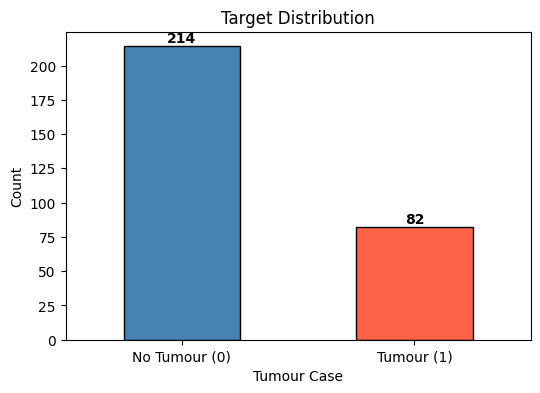

In [31]:
fig, ax = plt.subplots(figsize=(6, 4))
y.value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_xticklabels(['No Tumour (0)', 'Tumour (1)'], rotation=0)
ax.set_title('Target Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(y.value_counts()):
    ax.text(i, v + 3, str(v), ha='center', fontweight='bold')

plt.show()

In [32]:
symptom_cols = ['Café au lait (CLS)', 'Axillary Freckles', 'Inguinal Freckles',
                'Lisch Nodules', 'Dermal Neurofibromins', 'Plexiform Neurofibromins',
                'Optic Glioma', 'Skeletal Dysplasia', 'Learning Disability',
                'Hypertension', 'Astrocytoma', 'Hamartoma', 'Scoliosis', 'Other Symptoms']

In [33]:
# mean for a given symptom FOR A WHOLE GROUP OF PEOPLE
symptom_means = X[symptom_cols].mean()
symptom_means

Café au lait (CLS)          0.932432
Axillary Freckles           0.533784
Inguinal Freckles           0.270270
Lisch Nodules               0.280405
Dermal Neurofibromins       0.277027
Plexiform Neurofibromins    0.138514
Optic Glioma                0.158784
Skeletal Dysplasia          0.189189
Learning Disability         0.030405
Hypertension                0.016892
Astrocytoma                 0.016892
Hamartoma                   0.047297
Scoliosis                   0.043919
Other Symptoms              0.341216
dtype: float64

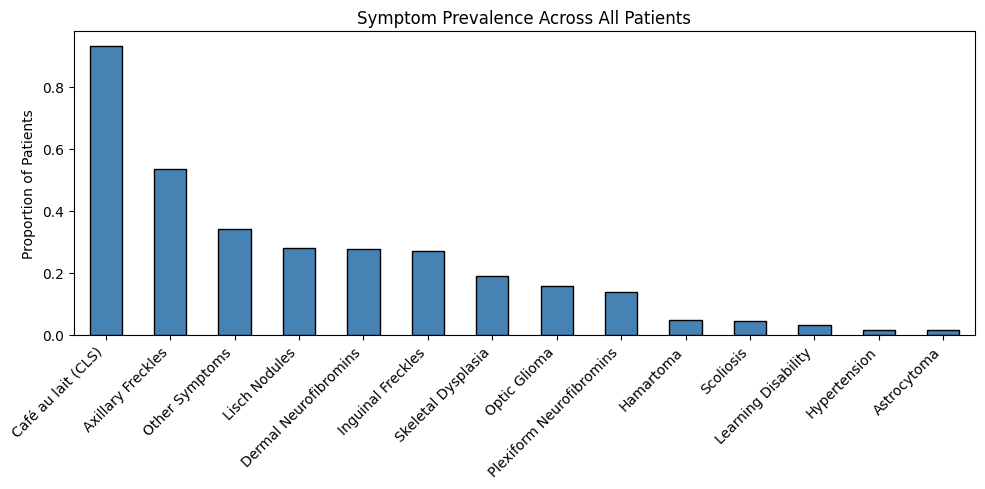

In [34]:
symptom_cols = ['Café au lait (CLS)', 'Axillary Freckles', 'Inguinal Freckles',
                'Lisch Nodules', 'Dermal Neurofibromins', 'Plexiform Neurofibromins',
                'Optic Glioma', 'Skeletal Dysplasia', 'Learning Disability',
                'Hypertension', 'Astrocytoma', 'Hamartoma', 'Scoliosis', 'Other Symptoms']

symptom_means = symptom_means.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
symptom_means.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Symptom Prevalence Across All Patients')
ax.set_ylabel('Proportion of Patients')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [35]:
# conclusion: the first and two last carry almost no information - they are candidates for dropping if the model sruggles 
symptom_means

Café au lait (CLS)          0.932432
Axillary Freckles           0.533784
Other Symptoms              0.341216
Lisch Nodules               0.280405
Dermal Neurofibromins       0.277027
Inguinal Freckles           0.270270
Skeletal Dysplasia          0.189189
Optic Glioma                0.158784
Plexiform Neurofibromins    0.138514
Hamartoma                   0.047297
Scoliosis                   0.043919
Learning Disability         0.030405
Hypertension                0.016892
Astrocytoma                 0.016892
dtype: float64

In [36]:
# correlation of symptoms with tumour development
symptom_by_target = X[symptom_cols].copy()
symptom_by_target["Tumour"] = y.values

In [37]:
symptom_by_target

,Café au lait (CLS),Axillary Freckles,Inguinal Freckles,Lisch Nodules,Dermal Neurofibromins,Plexiform Neurofibromins,Optic Glioma,Skeletal Dysplasia,Learning Disability,Hypertension,Astrocytoma,Hamartoma,Scoliosis,Other Symptoms,Tumour
0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1
1,1,1,0,0,1,0,0,0,0,0,0,0,0,1,1
2,1,1,0,0,1,0,0,1,0,0,0,0,0,1,1
3,1,1,0,1,0,1,0,0,0,0,0,0,0,1,1
4,1,1,1,0,0,0,1,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,1,1,0,0,0,0,1,0,0,0,0,0,0,1,1
292,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0
293,1,0,0,1,0,0,0,0,0,0,0,0,0,1,1
294,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [38]:
# group by tumour/no tumour and calculate means of all samples from individual groups
# [symptom_cols] used because we dont need Tumour column (its excluded from [symptom_cols])
means = symptom_by_target.groupby("Tumour")[symptom_cols].mean()

In [39]:
means

,Café au lait (CLS),Axillary Freckles,Inguinal Freckles,Lisch Nodules,Dermal Neurofibromins,Plexiform Neurofibromins,Optic Glioma,Skeletal Dysplasia,Learning Disability,Hypertension,Astrocytoma,Hamartoma,Scoliosis,Other Symptoms
Tumour,,,,,,,,,,,,,,
0,0.953271,0.556075,0.299065,0.252336,0.271028,0.121495,0.014019,0.163551,0.03271,0.018692,0.000000,0.046729,0.028037,0.186916
1,0.878049,0.475610,0.195122,0.353659,0.292683,0.182927,0.536585,0.256098,0.02439,0.012195,0.060976,0.048780,0.085366,0.743902


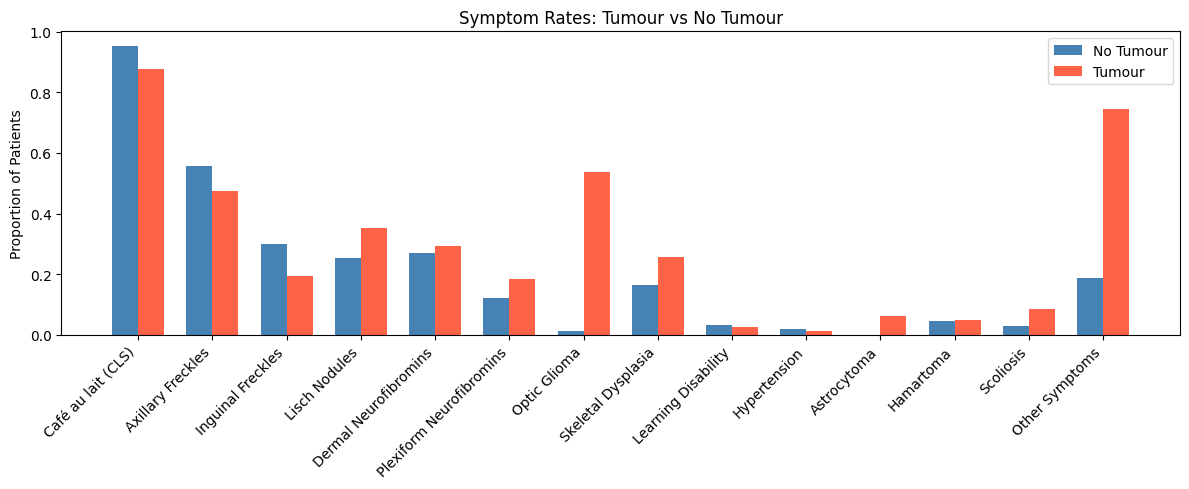

In [40]:
# graph showing the comparison of the means for tumour/no tumour cases 
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(symptom_cols))
width = 0.35

bars1 = ax.bar(x - width/2 , means.loc[0], width, label='No Tumour', 
               color='steelblue')
bars2 = ax.bar(x + width/2, means.loc[1], width, label='Tumour', 
              color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(symptom_cols, rotation=45, ha='right')
ax.set_title('Symptom Rates: Tumour vs No Tumour')
ax.set_ylabel('Proportion of Patients')
ax.legend()
plt.tight_layout()
plt.show()

In [41]:
means.loc[1] # tumour

Café au lait (CLS)          0.878049
Axillary Freckles           0.475610
Inguinal Freckles           0.195122
Lisch Nodules               0.353659
Dermal Neurofibromins       0.292683
Plexiform Neurofibromins    0.182927
Optic Glioma                0.536585
Skeletal Dysplasia          0.256098
Learning Disability         0.024390
Hypertension                0.012195
Astrocytoma                 0.060976
Hamartoma                   0.048780
Scoliosis                   0.085366
Other Symptoms              0.743902
Name: 1, dtype: float64

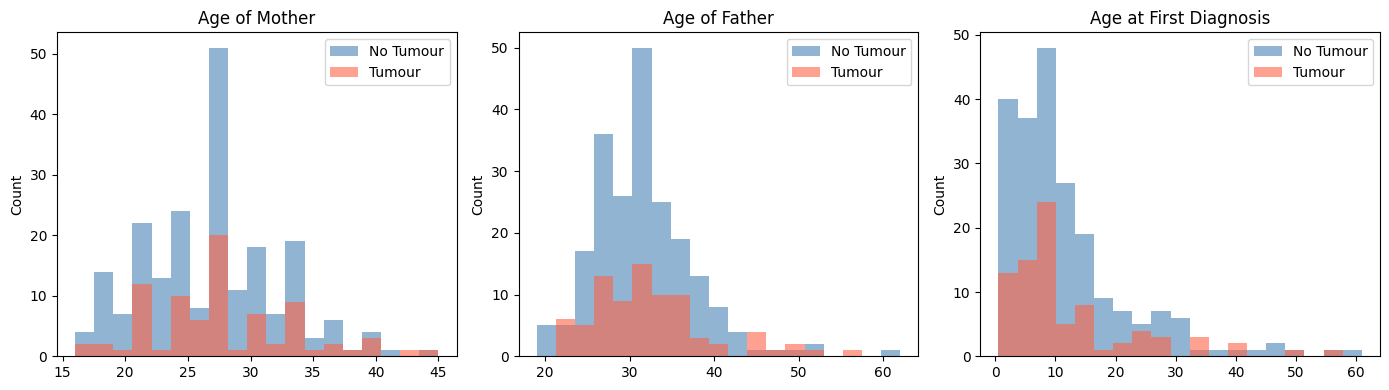

In [42]:
# age distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))



for ax, col in zip(axes, age_cols):
    bin = np.linspace(X[col].min(), X[col].max(), 20)
    ax.hist(X[col][y==0], bins=bin, alpha=0.6, color='steelblue', label='No Tumour')
    ax.hist(X[col][y==1], bins=bin, alpha=0.6, color='tomato', label='Tumour')
    ax.set_title(col)
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

In [43]:
X['Age at First Diagnosis'][y==0]

9      21.0
15     11.0
16      4.0
17      8.0
18     20.0
       ... 
287    10.0
289     3.0
290    11.0
292    31.0
294     2.0
Name: Age at First Diagnosis, Length: 214, dtype: float64

In [44]:
# consclusion: ages of father and mother look similar (the same medians) - probably weak predictors; 
# age of diagnosis need checking - might matter
# ages per Ages column for No tumour case
for col in age_cols:
    #print("Values:", X[col][y==0].values)
    print("Median:", X[col][y==0].median())
    

Median: 27.0
Median: 31.0
Median: 9.0


In [45]:
# ages per Ages column for tumour case
for col in age_cols:
    print("Values:", X[col][y==1].values)
    print("Median:",X[col][y==1].median())


Values: [30. 22. 28. 30. 27. 33. 33. 24. 24. 33. 27. 27. 28. 17. 32. 20. 27. 39.
 26. 43. 30. 33. 34. 29. 21. 26. 28. 28. 30. 27. 27. 32. 27. 21. 21. 21.
 21. 28. 23. 26. 44. 16. 40. 24. 30. 35. 25. 26. 28. 21. 36. 34. 25. 24.
 28. 38. 25. 26. 34. 19. 31. 33. 22. 22. 28. 27. 34. 21. 22. 27. 24. 27.
 24. 22. 24. 31. 26. 28. 19. 39. 27. 36.]
Median: 27.0
Values: [31. 29. 26. 34. 34. 39. 34. 34. 26. 52. 31. 31. 34. 27. 32. 28. 31. 33.
 29. 56. 28. 33. 35. 26. 25. 33. 30. 44. 35. 34. 31. 36. 36. 22. 23. 22.
 24. 28. 35. 27. 50. 24. 46. 30. 37. 37. 26. 40. 31. 23. 49. 33. 31. 29.
 45. 40. 30. 31. 31. 25. 37. 38. 27. 23. 31. 29. 47. 25. 26. 38. 29. 31.
 23. 26. 28. 35. 31. 32. 29. 45. 31. 36.]
Median: 31.0
Values: [ 5.  7.  9.  9.  1.  3.  4.  3.  9. 22. 29. 15. 13. 12.  7.  4. 15.  4.
  7.  5.  9.  6. 21. 16.  3. 14.  3.  4.  7. 15. 40. 17.  7.  6. 16.  9.
 28. 51.  7.  9.  6.  7.  7. 27.  8.  8.  8.  6. 35.  3. 11.  8. 25.  2.
  4. 12.  2.  3. 16. 34.  7.  7. 10.  8. 34.  4.  6. 56.  2.  1

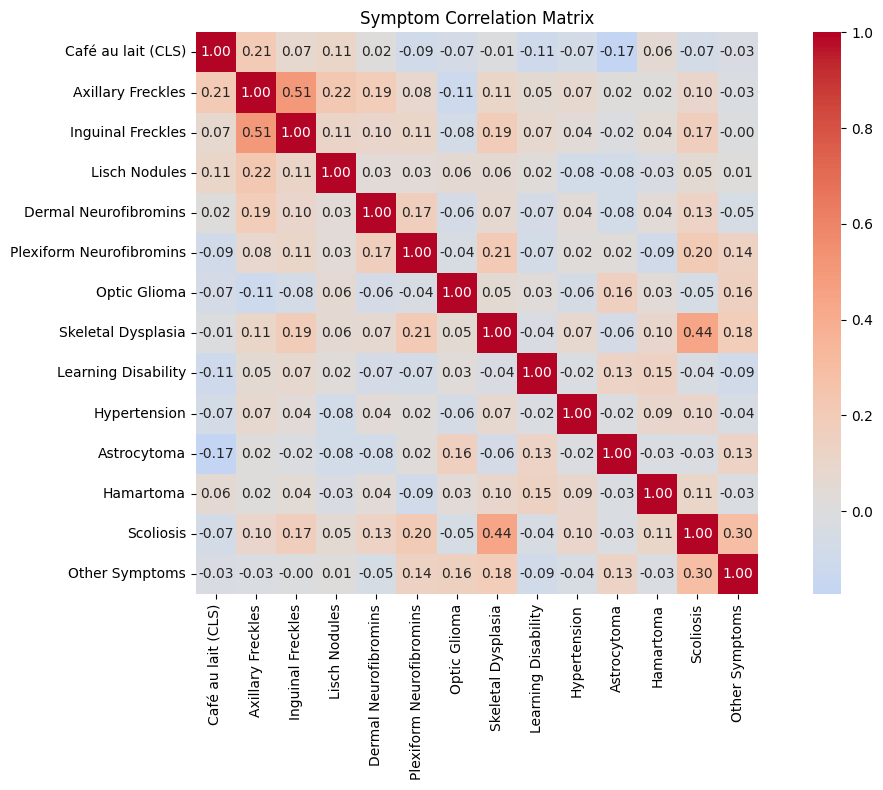

In [46]:
fig, ax = plt.subplots(figsize=(12, 8))
corr = X[symptom_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax, square=True)
ax.set_title('Symptom Correlation Matrix')
plt.tight_layout()
plt.show()

In [47]:
corr

,Café au lait (CLS),Axillary Freckles,Inguinal Freckles,Lisch Nodules,Dermal Neurofibromins,Plexiform Neurofibromins,Optic Glioma,Skeletal Dysplasia,Learning Disability,Hypertension,Astrocytoma,Hamartoma,Scoliosis,Other Symptoms
Café au lait (CLS),1.000000,0.207096,0.072902,0.108112,0.016257,-0.086879,-0.067186,-0.007430,-0.109110,-0.069160,-0.173606,0.059979,-0.073672,-0.033376
Axillary Freckles,0.207096,1.000000,0.507763,0.221560,0.185066,0.080671,-0.112808,0.105616,0.047171,0.069951,0.017399,0.016814,0.101157,-0.027313
Inguinal Freckles,0.072902,0.507763,1.000000,0.111223,0.099233,0.108325,-0.077071,0.191607,0.069452,0.038291,-0.020741,0.043586,0.166556,-0.004770
Lisch Nodules,0.108112,0.221560,0.111223,1.000000,0.033724,0.032732,0.058051,0.063317,0.020865,-0.081825,-0.081825,-0.032797,0.049722,0.010772
Dermal Neurofibromins,0.016257,0.185066,0.099233,0.033724,1.000000,0.167000,-0.062384,0.067200,-0.065652,0.036019,-0.081141,0.039887,0.125204,-0.047444
Plexiform Neurofibromins,-0.086879,0.080671,0.108325,0.032732,0.167000,1.000000,-0.040411,0.205839,-0.071007,0.023332,0.023332,-0.089343,0.200421,0.144603
Optic Glioma,-0.067186,-0.112808,-0.077071,0.058051,-0.062384,-0.040411,1.000000,0.049755,0.030738,-0.056949,0.158246,0.033837,-0.048006,0.155250
Skeletal Dysplasia,-0.007430,0.105616,0.191607,0.063317,0.067200,0.205839,0.049755,1.000000,-0.035302,0.070554,-0.063318,0.095548,0.443701,0.179967
Learning Disability,-0.109110,0.047171,0.069452,0.020865,-0.065652,-0.071007,0.030738,-0.035302,1.000000,-0.023212,0.129473,0.145927,-0.037954,-0.085945
Hypertension,-0.069160,0.069951,0.038291,-0.081825,0.036019,0.023332,-0.056949,0.070554,-0.023212,1.000000,-0.017182,0.094295,0.099843,-0.039042


In [48]:
# conclusion: values with corr > 0.4 are treated as strong positive correlated, but
# in our case max=0.51 for Axillary Freckles and Inguinal Freckles - for observation;
# we do not use PCA for some reasons:
#   1. in medical data we need to know every feature name, as it can carry some information to the doctor - with PCA we have PCA1, PCA2 etc
#   2. PCA is designed for continuous, numerical data - on binary data it provides weird "string-like" shapes that does not help the model learn better
#   3. in medical data the "signal" is usually hidden in one or two specific symptoms - PCA spreads the signal across all components which can make
#      it harder for a simple model to find the truth    
print("Case Type unique values:", X['Case Type'].dtype)


Case Type unique values: int64


In [49]:
### MODEL TRAINING 1 (NO PIPELINE, NO FOLDING, STANDARD SCALER USED MANUALLY) ###

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproducible
    stratify=y            # preserve 72/28 ratio in both splits (this follows directly from the data: 28% samples->Tumour)
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"\nTrain target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")


Train size: (236, 18)
Test size:  (60, 18)

Train target distribution:
Tumour Case
0    171
1     65
Name: count, dtype: int64

Test target distribution:
Tumour Case
0    43
1    17
Name: count, dtype: int64


In [50]:
X_train.index

Index([203,  73, 106, 101,  31, 209,  61, 163, 215,  71,
       ...
       188, 236,  37, 254,  94,  75, 123, 126, 122, 208],
      dtype='int64', length=236)

In [51]:
y_train.index

Index([203,  73, 106, 101,  31, 209,  61, 163, 215,  71,
       ...
       188, 236,  37, 254,  94,  75, 123, 126, 122, 208],
      dtype='int64', length=236)

In [52]:
print(X_train[age_cols].mean())
print(X_train[age_cols].std())

Age of Mother             26.923729
Age of Father             31.635593
Age at First Diagnosis    11.427966
dtype: float64
Age of Mother              5.492985
Age of Father              6.329486
Age at First Diagnosis    10.307150
dtype: float64


In [53]:
# Scale the age columns only - binary features don't need scaling
scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

In [54]:
X_train

,Case Type,Age of Mother,Age of Father,Age at First Diagnosis,Café au lait (CLS),Axillary Freckles,Inguinal Freckles,Lisch Nodules,Dermal Neurofibromins,Plexiform Neurofibromins,Optic Glioma,Skeletal Dysplasia,Learning Disability,Hypertension,Astrocytoma,Hamartoma,Scoliosis,Other Symptoms
203,1,26.0,40.0,6.0,1,0,0,0,1,1,0,0,0,0,0,0,0,0
73,1,36.0,30.0,3.0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
106,0,28.0,28.0,7.0,1,1,0,0,0,0,0,0,0,0,0,0,0,1
101,0,22.0,26.0,3.0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
31,0,19.0,23.0,15.0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,1,19.0,31.0,7.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
123,0,20.0,27.0,3.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
126,1,36.0,34.0,4.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
122,0,33.0,38.0,4.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [55]:
# fit() ONLY ON TRAINING SET!; scaler stores attributes calculated after fit()
X_train[age_cols] = scaler.fit_transform(X_train[age_cols]) 
# on the test set we perform only tranform
X_test[age_cols] = scaler.transform(X_test[age_cols])

# note: Tree models dont need scaled data since they are split it at thresholds, and it may even
# obscure the data (split on scaled "Tumour size" or "Age" is misleading - we'd need to unscale that to know real values);
# so in prod we use Pipelines for each model (standard scaled added only where is needed);
# BUT SCALING NEVER HURTS MODEL CALCULATIONS! 

In [56]:
print(scaler.mean_)   # original means
print(scaler.scale_)  # original stds

[26.92372881 31.63559322 11.4279661 ]
[ 5.48133471  6.31606139 10.28528969]


In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, RocCurveDisplay)

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',   # handles 72/28 imbalance
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
        random_state=42,
        eval_metric='logloss'
    )
}

In [58]:
results = {}
i = 0
for name, model in models.items():
    # train
    model.fit(X_train, y_train)
    
    # predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'model':  model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'roc_auc': roc_auc_score(y_test, y_prob)
    }
    
    # if i == 2:
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, 
        target_names=['No Tumour', 'Tumour']))
    print(f"ROC AUC: {results[name]['roc_auc']:.3f}")
    i += 1


  Logistic Regression
              precision    recall  f1-score   support

   No Tumour       0.97      0.81      0.89        43
      Tumour       0.67      0.94      0.78        17

    accuracy                           0.85        60
   macro avg       0.82      0.88      0.83        60
weighted avg       0.89      0.85      0.86        60

ROC AUC: 0.940

  Random Forest
              precision    recall  f1-score   support

   No Tumour       0.89      0.95      0.92        43
      Tumour       0.86      0.71      0.77        17

    accuracy                           0.88        60
   macro avg       0.87      0.83      0.85        60
weighted avg       0.88      0.88      0.88        60

ROC AUC: 0.951

  XGBoost
              precision    recall  f1-score   support

   No Tumour       0.93      0.88      0.90        43
      Tumour       0.74      0.82      0.78        17

    accuracy                           0.87        60
   macro avg       0.83      0.85      0.84    

In [59]:
results['XGBoost']

{'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, ...),
 'y_pred': array([0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
        0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,

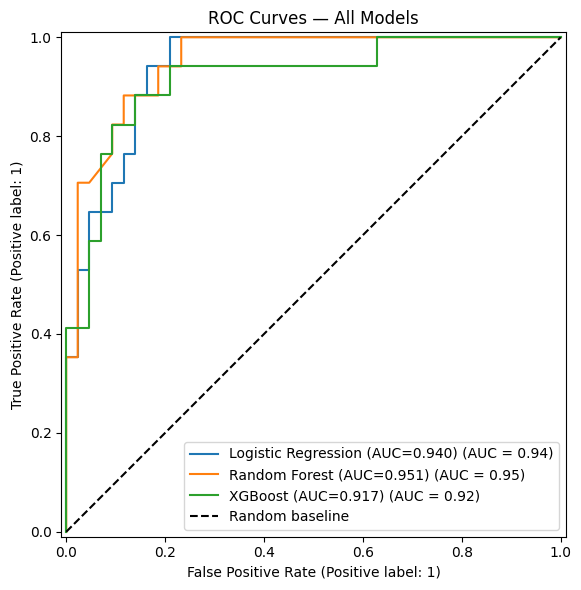

In [60]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, res in results.items():
    # probs are passed since ROC curve is created from checking each threshold 
    RocCurveDisplay.from_predictions(
        y_test, res['y_prob'],
        name=f"{name} (AUC={res['roc_auc']:.3f})",
        ax=ax
    )

ax.plot([0,1], [0,1], 'k--', label='Random baseline')
ax.set_title('ROC Curves — All Models')
ax.legend()
plt.tight_layout()
plt.show()

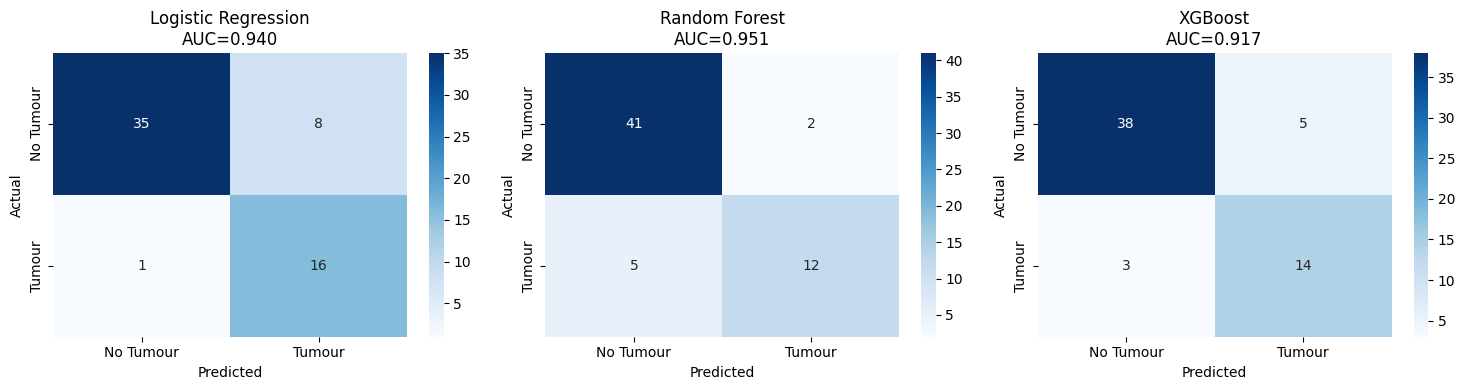

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Tumour', 'Tumour'],
                yticklabels=['No Tumour', 'Tumour'])
    ax.set_title(f'{name}\nAUC={res["roc_auc"]:.3f}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [62]:
cm

array([[38,  5],
       [ 3, 14]])

In [63]:
# conclusion: in medicine, and especially in case of cancer detection, FN are most dangerous (someone has a tumour but the model
# claims he doesn't), so Recall for Tumour is the most important; Logistic Regression wins in this small dataset; 
# rest of the models probably memorized too much the data; but Random Forest achieved very good results too - so we 
# are gonna show it also


In [64]:
### MODEL TRAINING 2 (FULL PIPELINE: SCALING, CV, FOLDING) ###

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

# removing spaces and brackets (models (eg XGBoost) sometimes struggle with special characters - especially 
# when generating visual reports)
X2 = nf1.drop(columns=['Tumour Case'])
y2 = nf1['Tumour Case']

X2.columns = X2.columns.str.replace(" ", "_").str.replace("(", "").str.replace(")", "")
y2.name = "Tumour_Case"


In [65]:
X2.columns, y2.name

(Index(['Case_Type', 'Age_of_Mother', 'Age_of_Father', 'Age_at_First_Diagnosis',
        'Café_au_lait_CLS', 'Axillary_Freckles', 'Inguinal_Freckles',
        'Lisch_Nodules', 'Dermal_Neurofibromins', 'Plexiform_Neurofibromins',
        'Optic_Glioma', 'Skeletal_Dysplasia', 'Learning_Disability',
        'Hypertension', 'Astrocytoma', 'Hamartoma', 'Scoliosis',
        'Other_Symptoms'],
       dtype='str'),
 'Tumour_Case')

In [66]:
X2.isnull().sum()

Case_Type                    0
Age_of_Mother               35
Age_of_Father               34
Age_at_First_Diagnosis       4
Café_au_lait_CLS             0
Axillary_Freckles            0
Inguinal_Freckles            0
Lisch_Nodules                0
Dermal_Neurofibromins        0
Plexiform_Neurofibromins     0
Optic_Glioma                 0
Skeletal_Dysplasia           0
Learning_Disability          0
Hypertension                 0
Astrocytoma                  0
Hamartoma                    0
Scoliosis                    0
Other_Symptoms               0
dtype: int64

In [67]:
# AGAIN: filling NaNs with median (the mean is sensitive to outliers we have in the dataset)
age_cols = ['Age_of_Mother', 'Age_of_Father', 'Age_at_First_Diagnosis']

filled2 = imptr.fit_transform(X2[age_cols])
filled2

array([[30. , 31. ,  5. ],
       [22. , 29. ,  7. ],
       [28. , 26. ,  9. ],
       [30. , 34. ,  9. ],
       [27. , 34. ,  1. ],
       [33. , 39. ,  3. ],
       [33. , 34. ,  4. ],
       [24. , 34. ,  3. ],
       [24. , 26. ,  9. ],
       [33. , 52. , 21. ],
       [33. , 52. , 22. ],
       [27. , 31. , 29. ],
       [27. , 31. , 15. ],
       [28. , 34. , 13. ],
       [17. , 27. , 12. ],
       [24. , 25. , 11. ],
       [27. , 31. ,  4. ],
       [25. , 33. ,  8. ],
       [20. , 24. , 20. ],
       [19. , 28. ,  3. ],
       [29. , 33. ,  2. ],
       [25. , 31. ,  4. ],
       [27. , 31. ,  9. ],
       [26. , 27. , 21. ],
       [25. , 19. , 15. ],
       [31. , 32. , 13. ],
       [30. , 29. , 11. ],
       [17. , 25. , 16. ],
       [27. , 31. ,  7. ],
       [25. , 29. ,  7. ],
       [23. , 33. , 22. ],
       [19. , 23. , 15. ],
       [40. , 40. ,  7. ],
       [31. , 37. ,  9. ],
       [28. , 31. ,  7. ],
       [41. , 43. , 12. ],
       [17. , 20. , 14. ],
 

In [68]:
X2[age_cols] = filled2

X2.isnull().sum().sum()

np.int64(0)

In [69]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, 
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproducible
    stratify=y2            # preserve 72/28 ratio in both splits (this follows directly from the data: 28% samples->Tumour)
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [70]:
# the ratio of tumour/no tumour is preserved
print(y_train2.value_counts(normalize=True))
print(y_test2.value_counts(normalize=True))

Tumour_Case
0    0.724576
1    0.275424
Name: proportion, dtype: float64
Tumour_Case
0    0.716667
1    0.283333
Name: proportion, dtype: float64


In [71]:
# Logistic Regression

# note: by default, in LR, the model marks patient as having a tumor if the probability >= 50% (threshold);
# we adjust this value in the further part below

lr_pipeline = Pipeline([         # note: Pipeline inherits the methods of the estimator in the chain (.predict(), .predict_proba() etc in LR)
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='elasticnet',
        solver='saga',           # SAGA is required for ElasticNet
        class_weight='balanced', # larger weight to the minority class based on frequency
        max_iter=5000,
        random_state=42
    ))
])

lr_params = {
    'model__C':        [0.001, 0.1, 1, 10, 100],      # inverse of regularization: C = 1/lambda (smaller C-> larger lambda -> 
                                                            # big penalty for large weights (i.e. small model weights))
    'model__l1_ratio':      [0.0, 0.25, 0.5, 0.75, 1.0],    # 0=L2, 1=L1, between=elasticnet
    'model__fit_intercept': [True, False],                  # T: add bias
    'model__warm_start':  [True, False]                     # T: reuse params model learned from a previous fit
    }

lr_search = GridSearchCV(
    lr_pipeline,
    param_grid=lr_params,
    cv=cv,
    scoring='recall',     # optimize for catching tumours
    n_jobs=-1,             # cpu cores usage (-1 = all)
)

lr_search.fit(X_train2, y_train2)
print("LR best params:", lr_search.best_params_)
print("LR best CV recall:", lr_search.best_score_.round(3))

/Users/user/Documents/python vscode/KURS_ALGORYTMY/PythonApplication1/nf1-classifier/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/user/Documents/python vscode/KURS_ALGORYTMY/PythonApplication1/nf1-classifier/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/user/Documents/python vscode/KURS_ALGORYTMY/P

LR best params: {'model__C': 0.1, 'model__fit_intercept': True, 'model__l1_ratio': 0.5, 'model__warm_start': True}
LR best CV recall: 0.985


/Users/user/Documents/python vscode/KURS_ALGORYTMY/PythonApplication1/nf1-classifier/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [72]:
a = cv.split(X_train2, y_train2)
for itr, (train, test) in enumerate(a):
    print(itr)
    print("train", train)
    print("test", test)

0
train [  0   3   4   5   7   8  11  13  15  16  18  19  20  21  22  24  27  28
  29  30  32  33  35  37  38  40  41  42  43  44  45  46  48  50  51  52
  53  54  55  56  57  58  60  62  64  65  66  68  69  70  71  73  74  75
  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93
  94  95  96  97  98 100 101 102 103 104 106 107 108 109 110 111 112 113
 114 115 117 119 121 122 123 124 125 126 127 128 129 130 131 132 133 134
 135 136 137 138 140 141 143 144 145 146 148 150 151 152 153 154 155 156
 157 158 159 160 161 162 163 164 165 167 168 169 170 171 174 175 177 179
 182 184 185 186 187 188 190 191 192 193 194 195 196 197 198 199 200 202
 204 205 206 207 208 209 211 212 213 215 216 217 219 220 221 223 224 225
 226 227 228 230 231 232 233 234]
test [  1   2   6   9  10  12  14  17  23  25  26  31  34  36  39  47  49  59
  61  63  67  72  99 105 116 118 120 139 142 147 149 166 172 173 176 178
 180 181 183 189 201 203 210 214 218 222 229 235]
1
train [  0   1   2   3   

In [73]:
lr_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [74]:
cv_res_df = pd.DataFrame(lr_search.cv_results_)
cv_res_df.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__fit_intercept,param_model__l1_ratio,param_model__warm_start,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.007690,0.004309,0.003320,0.001913,0.001,True,0.00,True,"{'model__C': 0.001, 'model__fit_intercept': Tr...",0.769231,0.923077,0.923077,0.538462,0.923077,0.815385,0.150738,83
1,0.008911,0.002608,0.003802,0.003551,0.001,True,0.00,False,"{'model__C': 0.001, 'model__fit_intercept': Tr...",0.769231,0.923077,0.923077,0.538462,0.923077,0.815385,0.150738,83
2,0.003655,0.001776,0.002398,0.001287,0.001,True,0.25,True,"{'model__C': 0.001, 'model__fit_intercept': Tr...",1.000000,0.000000,1.000000,1.000000,1.000000,0.800000,0.400000,85
3,0.003185,0.001460,0.001570,0.000138,0.001,True,0.25,False,"{'model__C': 0.001, 'model__fit_intercept': Tr...",1.000000,0.000000,1.000000,1.000000,1.000000,0.800000,0.400000,85
4,0.004625,0.001940,0.002081,0.000553,0.001,True,0.50,True,"{'model__C': 0.001, 'model__fit_intercept': Tr...",1.000000,0.000000,1.000000,1.000000,1.000000,0.800000,0.400000,85


<>:40: SyntaxWarning: invalid escape sequence '\p'
<>:40: SyntaxWarning: invalid escape sequence '\p'
/var/folders/4x/rgjkfkhn7ys5962p7g2yjf5w0000gn/T/ipykernel_20920/1748301634.py:40: SyntaxWarning: invalid escape sequence '\p'
  label=f"Mean ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})", lw=2, alpha=0.8
/Users/user/Documents/python vscode/KURS_ALGORYTMY/PythonApplication1/nf1-classifier/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/user/Documents/python vscode/KURS_ALGORYTMY/PythonApplication1/nf1-classifier/.venv/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.

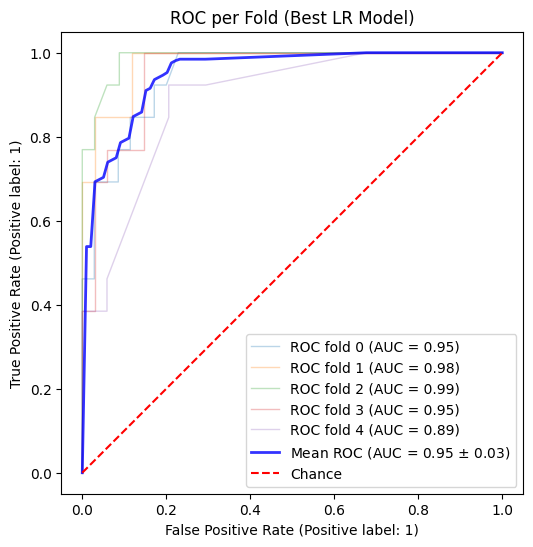

In [75]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import RocCurveDisplay, auc
from sklearn.base import clone

# 1. Grab your absolute best pipeline setup
best_model = clone(lr_search.best_estimator_)

fig, ax = plt.subplots(figsize=(8, 6))
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

# 2. Re-run the 5 folds manually on the BEST model configuration to plot the lines
for fold, (train_idx, test_idx) in enumerate(cv.split(X_train2, y_train2)):
    # Split data
    X_fold_train, X_fold_test = X_train2.iloc[train_idx], X_train2.iloc[test_idx]
    y_fold_train, y_fold_test = y_train2.iloc[train_idx], y_train2.iloc[test_idx]
    
    # Fit and plot curve for this fold
    best_model.fit(X_fold_train, y_fold_train)
    viz = RocCurveDisplay.from_estimator(
        best_model, X_fold_test, y_fold_test,
        name=f"ROC fold {fold}", alpha=0.3, lw=1, ax=ax
    )
    
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

# 3. Add the structural Mean ROC line
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

ax.plot(
    mean_fpr, mean_tpr, color="b",
    label=f"Mean ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})", lw=2, alpha=0.8
)

# 4. Standard formatting
ax.plot([0, 1], [0, 1], "r--", label="Chance")
ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05], title="ROC per Fold (Best LR Model)")
ax.legend(loc="lower right")
plt.show()

In [76]:
# note: 'model__C': 0.1 - mild regularization, model__l1_ratio': 0.5 - elasticnet (mix of L1 and L2)

results_lr = {}    
y_pred_lr = lr_search.predict(X_test2)
y_prob_lr = lr_search.predict_proba(X_test2)[:, 1]
results_lr['lr'] = {
    'model':  lr_search,
    'y_pred': y_pred_lr,
    'y_prob': y_prob_lr,
    'roc_auc': roc_auc_score(y_test2, y_prob_lr)
}

# results for default LR threshold 0.5 (mark patient)
print(f"\n{'='*50}")
print(f"  {'lr'} - default threshold 0.5")
print(f"{'='*50}")
# classification_report() method returns results for default 0.5 threshold
print(classification_report(y_test2, y_pred_lr, 
    target_names=['No Tumour', 'Tumour']))
print(f"ROC AUC: {results_lr['lr']['roc_auc']:.3f}")


  lr - default threshold 0.5
              precision    recall  f1-score   support

   No Tumour       1.00      0.79      0.88        43
      Tumour       0.65      1.00      0.79        17

    accuracy                           0.85        60
   macro avg       0.83      0.90      0.84        60
weighted avg       0.90      0.85      0.86        60

ROC AUC: 0.956


In [77]:
# NOTE: CALCULATING THIS WAY IS INEFFICIENT; THERE ARE OUT OF THE BOX FUNCTIONS FROM sklearn

# finding the best threshold 
from time import sleep
from sklearn.metrics import recall_score, precision_score, f1_score

# try every possible threshold
thresholds = np.arange(0.1, 0.9, 0.01)
recalls    = []
precisions = []
f1_scores  = []


for thresh in thresholds:
    y_pred_thresh = (y_prob_lr >= thresh).astype(int)

    # each score must be calculated separately to test different threshold values;
    # classification_report() returns text that doesnt allow simple computations
    recalls.append(recall_score(y_test2, y_pred_thresh, zero_division=0))
    precisions.append(precision_score(y_test2, y_pred_thresh, zero_division=0))
    f1_scores.append(f1_score(y_test2, y_pred_thresh, zero_division=0))

results_thresh = pd.DataFrame({
    'threshold': thresholds,
    'recall':    recalls,
    'precision': precisions,
    'f1':        f1_scores
})

print(results_thresh.tail(40))



    threshold    recall  precision        f1
40       0.50  1.000000   0.653846  0.790698
41       0.51  1.000000   0.653846  0.790698
42       0.52  1.000000   0.653846  0.790698
43       0.53  1.000000   0.680000  0.809524
44       0.54  1.000000   0.680000  0.809524
45       0.55  1.000000   0.680000  0.809524
46       0.56  1.000000   0.680000  0.809524
47       0.57  1.000000   0.680000  0.809524
48       0.58  1.000000   0.680000  0.809524
49       0.59  1.000000   0.680000  0.809524
50       0.60  1.000000   0.680000  0.809524
51       0.61  0.941176   0.695652  0.800000
52       0.62  0.823529   0.777778  0.800000
53       0.63  0.823529   0.777778  0.800000
54       0.64  0.823529   0.777778  0.800000
55       0.65  0.823529   0.777778  0.800000
56       0.66  0.705882   0.800000  0.750000
57       0.67  0.705882   0.800000  0.750000
58       0.68  0.588235   0.769231  0.666667
59       0.69  0.588235   0.909091  0.714286
60       0.70  0.588235   0.909091  0.714286
61       0

In [78]:
# note: sweet spot -> threshold = +/- 0.53

# all rows with recall = 1.0
max_recall = results_thresh[results_thresh['recall'] == 1.0]
# if some 1.0 recall found then find max precision row
if len(max_recall) > 0:
    best_thresh = max_recall.loc[max_recall['precision'].idxmax(), 'threshold'] # from max_recall localize row at index X
                                                                                # and print col Y from it: loc[idx, col]
# else pick max recall
else:
    best_thresh = results_thresh.loc[results_thresh['recall'].idxmax(), 'threshold']

best_thresh

np.float64(0.5299999999999998)

In [79]:
# note: 53% is optimal threshold for the model 

In [80]:
# OPTIMAL CALCULATION OF THE SCORES

from sklearn.metrics import precision_recall_curve

precisions_lr, recalls_lr, thresholds_lr = precision_recall_curve(y_test2, y_prob_lr)
# removing the last element so it matches the size of the thresholds_opt (there is N-1 thersholds)    
precisions_lr = precisions_lr[:-1]
recalls_lr = recalls_lr[:-1]
f1_lr = np.divide(
    2 * (precisions_lr * recalls_lr),
    precisions_lr + recalls_lr,
    out=np.zeros_like(precisions_lr),
    where=(precisions_lr + recalls_lr) != 0
)
df_thresh_lr = pd.DataFrame({
    'Threshold': thresholds_lr,
    'Precision': precisions_lr,
    'Recall': recalls_lr,
    'F1': f1_lr
})


In [81]:
def find_optimal_threshold(recalls, precisions, thresholds, model_name):

    recall_max = recalls.max()
    masked_precisions = np.where(recalls == recall_max, precisions, -1)
    best_idx = np.argmax(masked_precisions)

    print("MODEL:", model_name)
    print('masked', masked_precisions)
    print('bestidx', best_idx)
    print('thresholds', thresholds[best_idx])

    return thresholds[best_idx]

In [82]:
thresh_lr = find_optimal_threshold(recalls_lr, precisions_lr, thresholds_lr, 'LR')

MODEL: LR
masked [ 0.28333333  0.28813559  0.29310345  0.29824561  0.30357143  0.30909091
  0.31481481  0.32075472  0.32692308  0.34        0.34693878  0.35416667
  0.36170213  0.36956522  0.37777778  0.38636364  0.39534884  0.4047619
  0.41463415  0.425       0.43589744  0.44736842  0.45945946  0.47222222
  0.48571429  0.5         0.51515152  0.53125     0.5483871   0.56666667
  0.5862069   0.60714286  0.62962963  0.65384615  0.68       -1.
 -1.         -1.         -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.        ]
bestidx 34
thresholds 0.6066057488367282


In [83]:
print(f"Default threshold (0.5):")
y_pred_default = (y_prob_lr >= 0.5).astype(int)
print(classification_report(y_test2, y_pred_default, 
      target_names=['No Tumour', 'Tumour']))

print(f"\nOptimal threshold ({thresh_lr:.2f}):")
y_pred_optimal = (y_prob_lr >= thresh_lr).astype(int)
print(classification_report(y_test2, y_pred_optimal,
      target_names=['No Tumour', 'Tumour']))

Default threshold (0.5):
              precision    recall  f1-score   support

   No Tumour       1.00      0.79      0.88        43
      Tumour       0.65      1.00      0.79        17

    accuracy                           0.85        60
   macro avg       0.83      0.90      0.84        60
weighted avg       0.90      0.85      0.86        60


Optimal threshold (0.61):
              precision    recall  f1-score   support

   No Tumour       1.00      0.81      0.90        43
      Tumour       0.68      1.00      0.81        17

    accuracy                           0.87        60
   macro avg       0.84      0.91      0.85        60
weighted avg       0.91      0.87      0.87        60



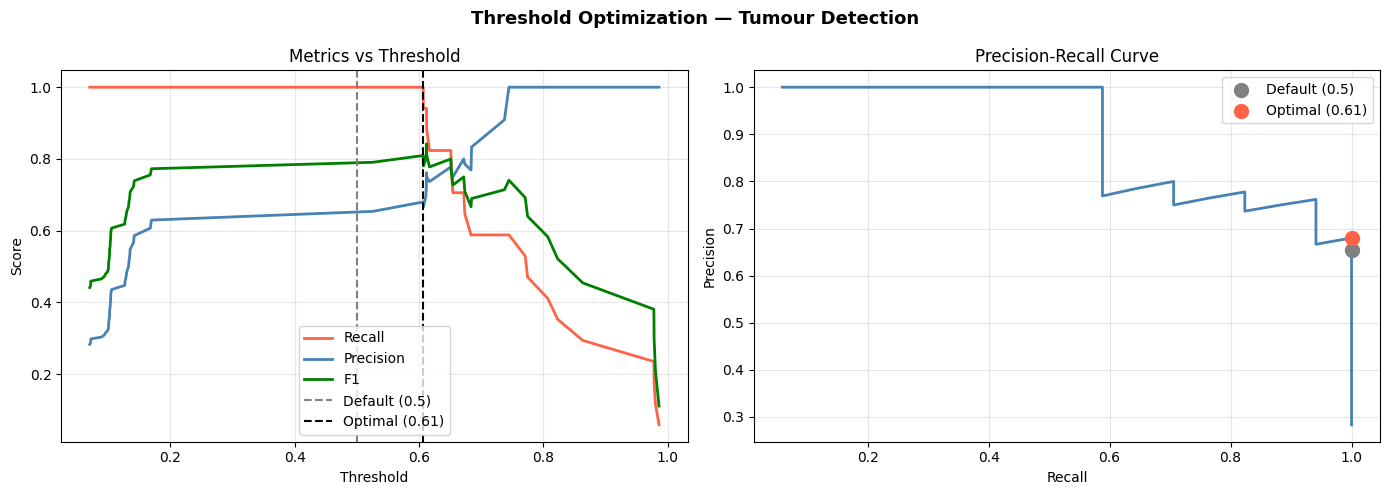


Optimal threshold selected: 0.61


In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot 1 — precision, recall, f1 vs threshold
axes[0].plot(thresholds_lr, recalls_lr,    label='Recall',    color='tomato',    lw=2)
axes[0].plot(thresholds_lr, precisions_lr, label='Precision', color='steelblue', lw=2)
axes[0].plot(thresholds_lr, f1_lr,  label='F1',        color='green',     lw=2)
axes[0].axvline(0.5,          color='gray',   linestyle='--', label='Default (0.5)')
axes[0].axvline(thresh_lr,  color='black',  linestyle='--', label=f'Optimal ({thresh_lr:.2f})')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Metrics vs Threshold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# plot 2 — precision-recall curve
axes[1].plot(recalls_lr, precisions_lr, color='steelblue', lw=2)
axes[1].scatter(
    # .sub() used to find thresh closest to 0.5; float are not precise: eg. 5.0000012 (as 5) so 
    # condition check as this will fail: "thresh == 0.5"
    df_thresh_lr.loc[df_thresh_lr['Threshold'].sub(0.5).abs().idxmin(), 'Recall'],
    df_thresh_lr.loc[df_thresh_lr['Threshold'].sub(0.5).abs().idxmin(), 'Precision'],
    color='gray', s=100, zorder=5, label='Default (0.5)'
)
axes[1].scatter(
    # "check every threshold possible, and find the index of the one that is closed to the thresh_lr,
    # and read Recall column value for that point and plot it on the X axis"
    df_thresh_lr.loc[df_thresh_lr['Threshold'].sub(thresh_lr).abs().idxmin(), 'Recall'],
    df_thresh_lr.loc[df_thresh_lr['Threshold'].sub(thresh_lr).abs().idxmin(), 'Precision'],
    color='tomato', s=100, zorder=5, label=f'Optimal ({thresh_lr:.2f})'
)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Threshold Optimization — Tumour Detection', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nOptimal threshold selected: {thresh_lr:.2f}")



In [85]:
idx_default = results_thresh['threshold'].sub(0.5).abs().idxmin()
idx_optimal = results_thresh['threshold'].sub(best_thresh).abs().idxmin()

row_default = results_thresh.loc[idx_default]
row_optimal = results_thresh.loc[idx_optimal]

In [86]:
results_thresh['threshold']

0     0.10
1     0.11
2     0.12
3     0.13
4     0.14
5     0.15
6     0.16
7     0.17
8     0.18
9     0.19
10    0.20
11    0.21
12    0.22
13    0.23
14    0.24
15    0.25
16    0.26
17    0.27
18    0.28
19    0.29
20    0.30
21    0.31
22    0.32
23    0.33
24    0.34
25    0.35
26    0.36
27    0.37
28    0.38
29    0.39
30    0.40
31    0.41
32    0.42
33    0.43
34    0.44
35    0.45
36    0.46
37    0.47
38    0.48
39    0.49
40    0.50
41    0.51
42    0.52
43    0.53
44    0.54
45    0.55
46    0.56
47    0.57
48    0.58
49    0.59
50    0.60
51    0.61
52    0.62
53    0.63
54    0.64
55    0.65
56    0.66
57    0.67
58    0.68
59    0.69
60    0.70
61    0.71
62    0.72
63    0.73
64    0.74
65    0.75
66    0.76
67    0.77
68    0.78
69    0.79
70    0.80
71    0.81
72    0.82
73    0.83
74    0.84
75    0.85
76    0.86
77    0.87
78    0.88
79    0.89
Name: threshold, dtype: float64

In [87]:
# feature importances (just weights in Logistic Regression)
coef = lr_search.best_estimator_.named_steps['model'].coef_[0]
coef

array([ 0.01096687,  0.01442718,  0.00840996,  0.        , -0.06960547,
       -0.00439679, -0.17195756,  0.14256088,  0.11739581,  0.        ,
        1.25212389,  0.        ,  0.        ,  0.        ,  0.14785585,
        0.        ,  0.        ,  1.24905499])

In [88]:
type(lr_search.best_estimator_)

sklearn.pipeline.Pipeline

In [89]:
lr_search.best_estimator_.steps

[('scaler', StandardScaler()),
 ('model',
  LogisticRegression(C=0.1, class_weight='balanced', l1_ratio=0.5, max_iter=5000,
                     penalty='elasticnet', random_state=42, solver='saga',
                     warm_start=True))]

In [90]:
# most significant features
feature_importance = pd.DataFrame({
    'Feature': X_train2.columns,
    'Importance': coef
}).sort_values(by='Importance', ascending=False)
feature_importance

,Feature,Importance
10,Optic_Glioma,1.252124
17,Other_Symptoms,1.249055
14,Astrocytoma,0.147856
7,Lisch_Nodules,0.142561
8,Dermal_Neurofibromins,0.117396
1,Age_of_Mother,0.014427
0,Case_Type,0.010967
2,Age_of_Father,0.008410
3,Age_at_First_Diagnosis,0.000000
11,Skeletal_Dysplasia,0.000000


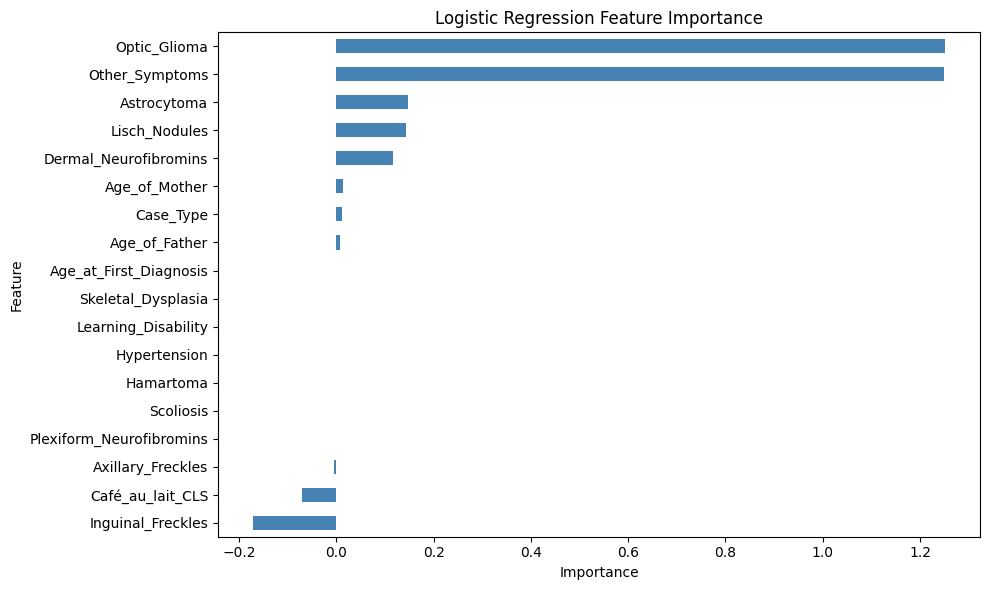

In [91]:
# plot
fig, ax = plt.subplots(figsize=(10, 6))
feature_importance.plot(kind='barh', x='Feature', y='Importance', 
                   ax=ax, color='steelblue', legend=False)
ax.set_title('Logistic Regression Feature Importance')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [92]:
print("Tumour:", np.sort(y_prob_lr[y_test2==1]))
print("\nIndexes:", y_test2[y_test==1].index)
print("\nNo Tumour:", np.sort(y_prob_lr[y_test2==0]))

Tumour: [0.60660575 0.61206034 0.61246782 0.65125278 0.65205261 0.67194871
 0.67371376 0.744641   0.77088192 0.77469022 0.8070296  0.82302245
 0.86345623 0.9777946  0.9781369  0.98026631 0.98607249]

Indexes: Index([93, 275, 60, 229, 253, 280, 230, 68, 11, 2, 175, 239, 172, 257, 262, 57,
       255],
      dtype='int64')

No Tumour: [0.07052335 0.07200594 0.07209703 0.07221846 0.08944097 0.09390985
 0.09571191 0.09912606 0.10046968 0.10046968 0.10085921 0.10127009
 0.10175303 0.10236151 0.10243552 0.10251403 0.10328992 0.1035816
 0.10402934 0.10418817 0.10452682 0.10563919 0.12667412 0.12739869
 0.12902339 0.13006594 0.13286581 0.13366927 0.13490248 0.13552317
 0.14086851 0.14210382 0.16790387 0.16975241 0.52563714 0.6072189
 0.61099372 0.61195744 0.61696032 0.65457897 0.68367648 0.68461751
 0.73745736]


In [93]:
# final note: much better results with C=0.1 (mild) compared C=0.01 (strong regularization), 8 False Positives; 
# increasing threshold to 0.53 we gain 1 False Positive less (that 0.52563714)

# Negative predictors (push away from tumour):
#   Inguinal Freckles  -0.172  ← interesting
#   Café au lait       -0.070  ← interesting
#   Axillary Freckles  -0.004

# -> patients with these symptoms and none other serious ones are less likely to develop tumours;


In [94]:
# Random Forest

from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        bootstrap=True,
        random_state=42
    ))
])

rf_params = {
    'model__n_estimators':       [50, 100, 200, 300],
    'model__max_depth':          [3, 5, 10, 15, None],
    'model__min_samples_split':  [2, 5, 10, 20],
    'model__min_samples_leaf':   [1, 2, 4, 8],
    'model__max_features':       ['sqrt', 'log2', 0.3, 0.5],
    'model__max_samples':        [0.6, 0.8, None],                  # max samples used to train each tree (more diversity -> better variance reduction)
    'model__criterion':          ['gini', 'entropy', 'log_loss']
}

# we dont choose GridSearch since there are about 23k combinations - cpu killer;
# so first we check parameters that affect recall the most via RandomizedCV, and then - 
# from this group, we will check all possible combinations using GridSearchCV
rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_params,
    n_iter=50,                          # try only 50 random combinations, not 23,040
    cv=cv,
    scoring='recall',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train2, y_train2)
print("RF best params:", rf_search.best_params_)
print("RF best CV recall:", rf_search.best_score_.round(3))

RF best params: {'model__n_estimators': 300, 'model__min_samples_split': 20, 'model__min_samples_leaf': 8, 'model__max_samples': 0.8, 'model__max_features': 0.5, 'model__max_depth': 5, 'model__criterion': 'entropy'}
RF best CV recall: 0.969


In [95]:
y_train2.value_counts()

Tumour_Case
0    171
1     65
Name: count, dtype: int64

In [178]:
rf_search.best_estimator_[1].estimators_[0].criterion

'entropy'

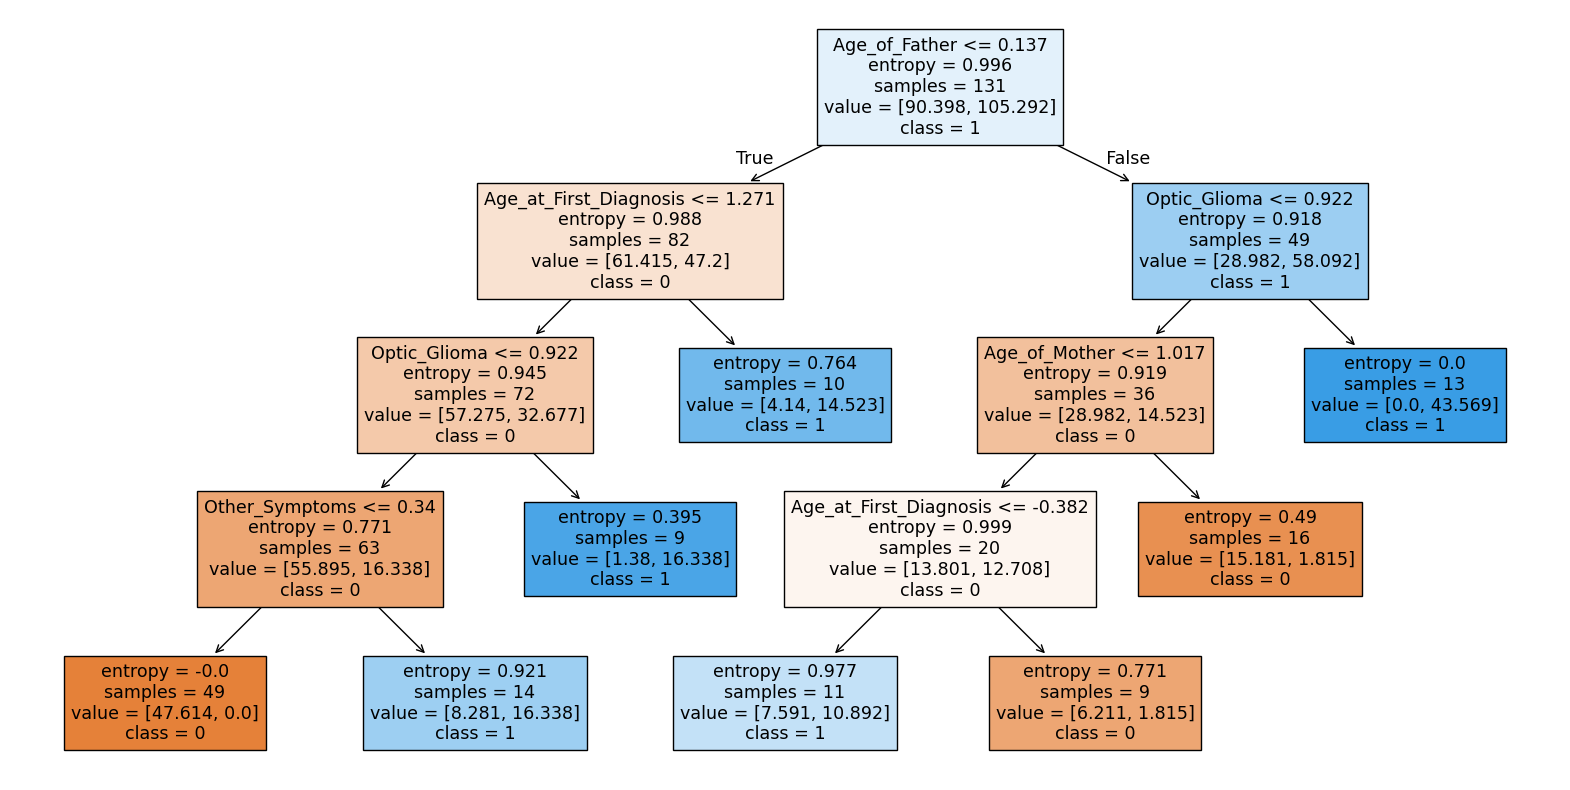

In [97]:
from sklearn.tree import plot_tree
rf_tree = rf_search.best_estimator_[1].estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(rf_tree, feature_names=X_test2.columns, class_names=['0', '1'], filled=True) # class = 1 -> tumour
plt.show()

In [98]:
# note: typically values in value=[] should be integers, since this is the number of samples of each class; but here - class_weight='balanced' assigns 
# different weights for each, eg: 0.56, 3.51, so we get float: 
#   w = tot_samples / (num_of_classes * samples_in_concrete_class)
#   w1 = 236 / (2 * 171) = 0.69         No tumour cases
#   w2 = 236 / (2 * 65) = 1.81          Tumour cases

# also note: it would be nice to have non-scaled values so the doctor could easily read the splits:

    # continuous_cols = ['Age_of_Mother', 'Age_of_Father', 'Age_at_First_Diagnosis']
    # binary_cols     = [c for c in X_tr.columns if c not in continuous_cols]

    # preprocessor = ColumnTransformer([
    #     ('scale', StandardScaler(), continuous_cols),
    #     ('pass',  'passthrough',    binary_cols)
    # ], remainder='drop')

    # rf_pipeline = Pipeline([
    #     ('preprocessor', preprocessor),
    #     ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
    # ])

In [99]:
# check paramameter combinations

cv_results_rf = pd.DataFrame(rf_search.cv_results_)
cv_results_rf.head(3)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_estimators,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_samples,param_model__max_features,param_model__max_depth,param_model__criterion,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.163189,0.012509,0.012828,0.004667,200,5,4,None,log2,None,entropy,"{'model__n_estimators': 200, 'model__min_sampl...",1.0,0.846154,1.0,0.769231,0.923077,0.907692,0.089707,26
1,0.043174,0.003799,0.006862,0.001612,50,20,2,0.8,sqrt,5,gini,"{'model__n_estimators': 50, 'model__min_sample...",1.0,1.000000,1.0,0.846154,0.923077,0.953846,0.061538,2
2,0.153816,0.014597,0.013954,0.003634,200,20,1,0.6,sqrt,10,entropy,"{'model__n_estimators': 200, 'model__min_sampl...",1.0,1.000000,1.0,0.769231,0.923077,0.938462,0.089707,6


In [100]:
# select significant columns 
cols_rf = [col for col in cv_results_rf if col.startswith('param_')]
cols_rf += ['mean_test_score']
cols_rf

['param_model__n_estimators',
 'param_model__min_samples_split',
 'param_model__min_samples_leaf',
 'param_model__max_samples',
 'param_model__max_features',
 'param_model__max_depth',
 'param_model__criterion',
 'mean_test_score']

In [101]:
important_cv_results_rf = cv_results_rf[cols_rf].sort_values('mean_test_score', ascending=False)
important_cv_results_rf.head(10)

,param_model__n_estimators,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_samples,param_model__max_features,param_model__max_depth,param_model__criterion,mean_test_score
18,300,20,8,0.8,0.5,5,entropy,0.969231
1,50,20,2,0.8,sqrt,5,gini,0.953846
22,300,10,1,None,0.5,3,entropy,0.953846
12,200,2,1,0.8,0.5,3,log_loss,0.953846
36,100,20,8,0.8,0.5,15,gini,0.953846
8,200,10,1,0.6,0.5,3,entropy,0.938462
29,100,10,4,None,sqrt,3,log_loss,0.938462
33,200,20,1,0.6,sqrt,15,log_loss,0.938462
49,50,10,2,None,log2,5,log_loss,0.938462
35,200,20,4,0.6,0.3,15,gini,0.938462


In [102]:
# NOTE: now we should choose the most significant features from the results above and use GridSearchCV to check all combinations;
# but i've already done it, and the results for this small dataset are almost identical, so we omit these calculations (below)


# rf_grid_params = {
#     'model__n_estimators':     [150, 300],          # Focused around your top rows
#     'model__max_depth':        [3, 4, 5],           # Zooming in on the 3-5 sweet spot
#     'model__max_features':     [0.4, 0.5, 0.6],     # Zooming in around 0.5
#     'model__max_samples':      [0.8],               # Locked in at your best value
#     'model__min_samples_split':[10, 20, 30]             # Testing the stable ranges from your table
# }

# # Total combinations: 36 
# rf_grid_search = GridSearchCV(
#     rf_pipeline, # using your existing RF pipeline
#     param_grid=rf_grid_params,
#     cv=cv,
#     scoring='recall',
#     n_jobs=-1
# )

# rf_grid_search.fit(X_train2, y_train2)
# print("RF Grid Best Params:", rf_grid_search.best_params_)

In [103]:
# predict labels and probabilities with the params selected by RandomizedCV
y_pred_rf = rf_search.predict(X_test2)
y_prob_rf = rf_search.predict_proba(X_test2)[:, 1]

In [104]:
y_pred_rf, y_prob_rf


(array([0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
        0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0]),
 array([0.09430089, 0.72381304, 0.61716421, 0.77184248, 0.09449033,
        0.07696796, 0.07114635, 0.16984118, 0.70742443, 0.06776012,
        0.66828594, 0.10364579, 0.05273234, 0.73572845, 0.96102857,
        0.59600397, 0.05693703, 0.07543401, 0.03389718, 0.91332319,
        0.07554339, 0.64605611, 0.06376155, 0.06633421, 0.70305806,
        0.1579521 , 0.13087352, 0.70890258, 0.08371435, 0.96355168,
        0.13113095, 0.71865468, 0.66346149, 0.04348387, 0.64596906,
        0.0368019 , 0.65793838, 0.65278601, 0.03200839, 0.61966435,
        0.05180645, 0.68837186, 0.90064431, 0.11784462, 0.12125291,
        0.03117657, 0.0517278 , 0.07510823, 0.66506914, 0.13043486,
        0.05527812, 0.12334031, 0.08172577, 0.06081499, 0.79068492,
        0.46591542, 0.50760791, 0.07830318, 0.

In [105]:
print(classification_report(y_test2, y_pred_rf, target_names=['No tumour', 'Tumour']))
print(f"ROC AUC: {roc_auc_score(y_test2, y_pred_rf):.3f}")
print("\nTumour probabilities:")
print(np.sort(y_prob_rf[y_test2 == 1]))
print("\nNo Tumour probabilities:")
print(np.sort(y_prob_rf[y_test2 == 0]))


              precision    recall  f1-score   support

   No tumour       0.97      0.79      0.87        43
      Tumour       0.64      0.94      0.76        17

    accuracy                           0.83        60
   macro avg       0.81      0.87      0.82        60
weighted avg       0.88      0.83      0.84        60

ROC AUC: 0.866

Tumour probabilities:
[0.46591542 0.50760791 0.59600397 0.65278601 0.66346149 0.66506914
 0.66828594 0.68837186 0.70742443 0.70890258 0.71865468 0.73572845
 0.79068492 0.90064431 0.91332319 0.96102857 0.96355168]

No Tumour probabilities:
[0.02025701 0.03117657 0.03200839 0.03389718 0.0368019  0.04348387
 0.0517278  0.05180645 0.05273234 0.05527812 0.05693703 0.06081499
 0.06376155 0.06633421 0.06776012 0.07114635 0.07510823 0.07543401
 0.07554339 0.07696796 0.07830318 0.08172577 0.08371435 0.09430089
 0.09449033 0.10364579 0.11784462 0.12125291 0.12334031 0.13043486
 0.13087352 0.13113095 0.1579521  0.16984118 0.55502522 0.61716421
 0.61966435 0.64

In [106]:
# finding the best threshold (INEFFICIENT WAY)

recalls, precisions, f1_scores = [], [], []

for thresh in thresholds:
    y_pred_thresh = (y_prob_rf >= thresh).astype(int)
    recalls.append(recall_score(y_test2, y_pred_thresh, zero_division=0))
    precisions.append(precision_score(y_test2, y_pred_thresh, zero_division=0))
    f1_scores.append(f1_score(y_test2, y_pred_thresh, zero_division=0))

results_thresh_rf = pd.DataFrame({
    'threshold': thresholds,
    'recall':    recalls,
    'precision': precisions,
    'f1':        f1_scores
})

# rows where recall is 1.0
perfect_recall_rf = results_thresh_rf[results_thresh_rf['recall'] == 1.0]

if len(perfect_recall_rf) > 0:
    # find max 'precision' value
    max_precision_rf = perfect_recall_rf['precision'].max()
    # all rows with that max value, and then pick the one with the highest threshold
    best_row_rf   = perfect_recall_rf[
        perfect_recall_rf['precision'] == max_precision_rf
    ].sort_values('threshold', ascending=False).iloc[0]

else:
    print("No threshold achieves perfect recall for RF")
    

In [107]:
print("Recall == 1.0 rows:\n", perfect_recall_rf)


Recall == 1.0 rows:
     threshold  recall  precision        f1
0        0.10     1.0   0.485714  0.653846
1        0.11     1.0   0.500000  0.666667
2        0.12     1.0   0.515152  0.680000
3        0.13     1.0   0.548387  0.708333
4        0.14     1.0   0.607143  0.755556
5        0.15     1.0   0.607143  0.755556
6        0.16     1.0   0.629630  0.772727
7        0.17     1.0   0.653846  0.790698
8        0.18     1.0   0.653846  0.790698
9        0.19     1.0   0.653846  0.790698
10       0.20     1.0   0.653846  0.790698
11       0.21     1.0   0.653846  0.790698
12       0.22     1.0   0.653846  0.790698
13       0.23     1.0   0.653846  0.790698
14       0.24     1.0   0.653846  0.790698
15       0.25     1.0   0.653846  0.790698
16       0.26     1.0   0.653846  0.790698
17       0.27     1.0   0.653846  0.790698
18       0.28     1.0   0.653846  0.790698
19       0.29     1.0   0.653846  0.790698
20       0.30     1.0   0.653846  0.790698
21       0.31     1.0   0.653846 

In [108]:
print("Best threshold:\n", best_row_rf)

Best threshold:
 threshold    0.460000
recall       1.000000
precision    0.653846
f1           0.790698
Name: 36, dtype: float64


In [109]:
# OTPIMAL WAY TO FIND A THRESHOLD
precisions_rf, recalls_rf, thresholds_rf = precision_recall_curve(
    y_test2, y_prob_rf
)

# Remove the last element so it matches the size of thresholds_rf
# (there are N-1 thresholds)
precisions_rf = precisions_rf[:-1]
recalls_rf = recalls_rf[:-1]

f1_rf = np.divide(
    2 * (precisions_rf * recalls_rf),
    precisions_rf + recalls_rf,
    out=np.zeros_like(precisions_rf),
    where=(precisions_rf + recalls_rf) != 0
)

df_thresh_rf = pd.DataFrame({
    'Threshold': thresholds_rf,
    'Precision': precisions_rf,
    'Recall': recalls_rf,
    'F1': f1_rf
})

In [110]:
df_thresh_rf

,Threshold,Precision,Recall,F1
0,0.020257,0.283333,1.000000,0.441558
1,0.031177,0.288136,1.000000,0.447368
2,0.032008,0.293103,1.000000,0.453333
3,0.033897,0.298246,1.000000,0.459459
4,0.036802,0.303571,1.000000,0.465753
5,0.043484,0.309091,1.000000,0.472222
6,0.051728,0.314815,1.000000,0.478873
7,0.051806,0.320755,1.000000,0.485714
8,0.052732,0.326923,1.000000,0.492754
9,0.055278,0.333333,1.000000,0.500000


In [111]:
thresh_rf = find_optimal_threshold(recalls_rf, precisions_rf, thresholds_rf, 'RF')

MODEL: RF
masked [ 0.28333333  0.28813559  0.29310345  0.29824561  0.30357143  0.30909091
  0.31481481  0.32075472  0.32692308  0.33333333  0.34        0.34693878
  0.35416667  0.36170213  0.36956522  0.37777778  0.38636364  0.39534884
  0.4047619   0.41463415  0.425       0.43589744  0.44736842  0.45945946
  0.47222222  0.48571429  0.5         0.51515152  0.53125     0.5483871
  0.56666667  0.5862069   0.60714286  0.62962963  0.65384615 -1.
 -1.         -1.         -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.         -1.        ]
bestidx 34
thresholds 0.46591541610180476


In [112]:
print("RF — Default threshold (0.50):")
print(classification_report(y_test2, y_pred_rf,
      target_names=['No Tumour', 'Tumour']))

print(f"RF — Optimal threshold {thresh_rf:.2f}:")
y_pred_rf_optimal = (y_prob_rf >= thresh_rf).astype(int)
print(classification_report(y_test2, y_pred_rf_optimal,
      target_names=['No Tumour', 'Tumour']))
print(f"ROC AUC: {roc_auc_score(y_test2, y_prob_rf):.3f}\n\n")


RF — Default threshold (0.50):
              precision    recall  f1-score   support

   No Tumour       0.97      0.79      0.87        43
      Tumour       0.64      0.94      0.76        17

    accuracy                           0.83        60
   macro avg       0.81      0.87      0.82        60
weighted avg       0.88      0.83      0.84        60

RF — Optimal threshold 0.47:
              precision    recall  f1-score   support

   No Tumour       1.00      0.79      0.88        43
      Tumour       0.65      1.00      0.79        17

    accuracy                           0.85        60
   macro avg       0.83      0.90      0.84        60
weighted avg       0.90      0.85      0.86        60

ROC AUC: 0.933




In [113]:
# Checking that one not caught patient (first position below)

print("\nTumour probabilities:")
print(np.sort(y_prob_rf[y_test2 == 1])) 


Tumour probabilities:
[0.46591542 0.50760791 0.59600397 0.65278601 0.66346149 0.66506914
 0.66828594 0.68837186 0.70742443 0.70890258 0.71865468 0.73572845
 0.79068492 0.90064431 0.91332319 0.96102857 0.96355168]


In [114]:
# patients with tumours 
tumour_indices = y_test2[y_test2 == 1].index
tumour_probs = y_prob_rf[y_test2 == 1]          # probability of tumour occurence for the above indices

tumour_indices, tumour_probs

(Index([93, 275, 60, 229, 253, 280, 230, 68, 11, 2, 175, 239, 172, 257, 262, 57,
        255],
       dtype='int64'),
 array([0.70742443, 0.66828594, 0.73572845, 0.96102857, 0.59600397,
        0.91332319, 0.70890258, 0.96355168, 0.71865468, 0.66346149,
        0.65278601, 0.68837186, 0.90064431, 0.66506914, 0.79068492,
        0.46591542, 0.50760791]))

In [115]:
# pair each tumour patient with their predicted probability
tumour_probs_table = pd.DataFrame({
    'original_index': tumour_indices,
    'probability':    tumour_probs
}).sort_values('probability')


In [116]:
# not caught sample (which have tumor) is at the first position - idx 57
tumour_probs_table.head(5)

,original_index,probability
15,57,0.465915
16,255,0.507608
4,253,0.596004
10,175,0.652786
9,2,0.663461


In [117]:
ambiguous_idx = tumour_probs_table.iloc[0]['original_index']

# Misclassified patient
print(f"Ambiguous patient index: {ambiguous_idx:.0f}")
print(f"Predicted probability:   {tumour_probs_table.iloc[0]['probability']:.3f}")
print(f"\nPatient features:")
print(X_test2.loc[ambiguous_idx])
print(f"\nTrue label: {y_test2.loc[ambiguous_idx]}")

Ambiguous patient index: 57
Predicted probability:   0.466

Patient features:
Case_Type                    0.0
Age_of_Mother               20.0
Age_of_Father               28.0
Age_at_First_Diagnosis       4.0
Café_au_lait_CLS             1.0
Axillary_Freckles            0.0
Inguinal_Freckles            0.0
Lisch_Nodules                0.0
Dermal_Neurofibromins        0.0
Plexiform_Neurofibromins     0.0
Optic_Glioma                 0.0
Skeletal_Dysplasia           0.0
Learning_Disability          0.0
Hypertension                 0.0
Astrocytoma                  0.0
Hamartoma                    1.0
Scoliosis                    0.0
Other_Symptoms               1.0
Name: 57, dtype: float64

True label: 1


In [118]:
# Feature importances 

# (feature_importances_ for a Random Forest measures something called Gini Importance or Mean Decrease in Impurity;
# it calculates impurity drop after specific feature's split in each tree, averages results, normalizes them so 
# that they sums to 1.0)

rf_importance = pd.DataFrame({
        'Feature': X_train2.columns,
        'Importance': rf_search.best_estimator_.named_steps['model'].feature_importances_   
}).sort_values('Importance', ascending=False)

In [119]:
rf_search.best_estimator_.named_steps['model'].feature_importances_

array([0.00790173, 0.04196754, 0.05004756, 0.04527959, 0.00131547,
       0.01747986, 0.01963141, 0.00984979, 0.00880766, 0.00658905,
       0.37314011, 0.00480903, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.41318118])

In [120]:
rf_importance

,Feature,Importance
17,Other_Symptoms,0.413181
10,Optic_Glioma,0.373140
2,Age_of_Father,0.050048
3,Age_at_First_Diagnosis,0.045280
1,Age_of_Mother,0.041968
6,Inguinal_Freckles,0.019631
5,Axillary_Freckles,0.017480
7,Lisch_Nodules,0.009850
8,Dermal_Neurofibromins,0.008808
0,Case_Type,0.007902


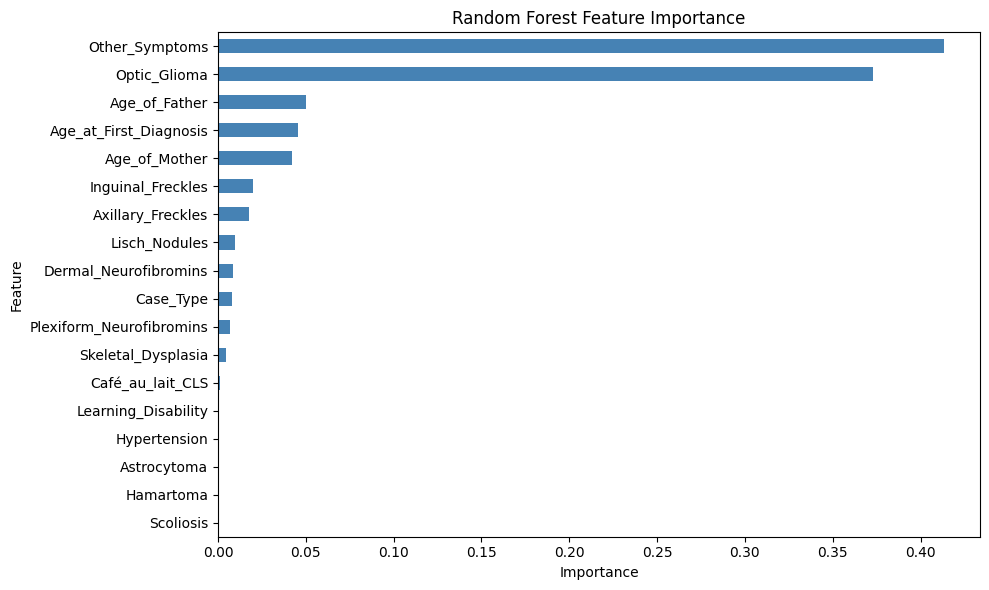

In [121]:
# plot
fig, ax = plt.subplots(figsize=(10, 6))
rf_importance.plot(kind='barh', x='Feature', y='Importance', 
                   ax=ax, color='steelblue', legend=False)
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [122]:
# XGBoost

# imbalance check
scale_pos = y_train2.value_counts()[0] / y_train2.value_counts()[1]
print(f"scale_pos_weight: {scale_pos:.2f}")

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        scale_pos_weight=scale_pos,  # handles 72/28 imbalance
        random_state=42,
        eval_metric='logloss',
        verbosity=0                  # suppress training output
    ))
])

xgb_params = {
    'model__n_estimators':       [50, 100, 200, 300],
    'model__max_depth':          [3, 4, 5, 6],
    'model__learning_rate':      [0.01, 0.05, 0.1, 0.2],
    'model__subsample':          [0.6, 0.8, 1.0],
    'model__colsample_bytree':   [0.6, 0.8, 1.0],
    'model__gamma':              [0, 0.1, 0.5, 1.0, 2.0],
    'model__reg_lambda':         [0.5, 1.0, 2.0, 5.0, 10.0],
    'model__reg_alpha':          [0, 0.1, 0.5, 1.0, 5.0],
    'model__min_child_weight':   [1, 3, 5, 7],
    'model__colsample_bylevel':  [0.6, 0.8, 1.0],
    'model__max_delta_step':     [0, 1, 5]
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=50,
    cv=cv,
    scoring='recall',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train2, y_train2)
print("XGB best params:", xgb_search.best_params_)
print("XGB best CV recall:", xgb_search.best_score_.round(3))

scale_pos_weight: 2.63
XGB best params: {'model__subsample': 1.0, 'model__reg_lambda': 2.0, 'model__reg_alpha': 5.0, 'model__n_estimators': 100, 'model__min_child_weight': 5, 'model__max_depth': 5, 'model__max_delta_step': 1, 'model__learning_rate': 0.05, 'model__gamma': 2.0, 'model__colsample_bytree': 1.0, 'model__colsample_bylevel': 0.8}
XGB best CV recall: 0.985


In [123]:
y_pred_xgb = xgb_search.best_estimator_.predict(X_test2)
y_prob_xgb = xgb_search.best_estimator_.predict_proba(X_test2)[:, 1]

print(classification_report(y_test2, y_pred_xgb,
      target_names=['No Tumour', 'Tumour']))
print(f"ROC AUC: {roc_auc_score(y_test2, y_prob_xgb):.3f}")

print("\nTumour probabilities:")
print(np.sort(y_prob_xgb[y_test2 == 1]))
print("\nNo Tumour probabilities:")
print(np.sort(y_prob_xgb[y_test2 == 0]))

              precision    recall  f1-score   support

   No Tumour       1.00      0.79      0.88        43
      Tumour       0.65      1.00      0.79        17

    accuracy                           0.85        60
   macro avg       0.83      0.90      0.84        60
weighted avg       0.90      0.85      0.86        60

ROC AUC: 0.930

Tumour probabilities:
[0.51921743 0.60995054 0.61672825 0.6631581  0.67226446 0.6762871
 0.71954936 0.76453066 0.86242193 0.86242193 0.86242193 0.86242193
 0.88641566 0.88813895 0.902241   0.91997933 0.91997933]

No Tumour probabilities:
[0.06174678 0.06174678 0.06174678 0.06174678 0.06174678 0.06277797
 0.06277797 0.06277797 0.06697541 0.06697541 0.06697541 0.06808759
 0.06907801 0.06907801 0.06907801 0.06907801 0.06907801 0.06907801
 0.06907801 0.06907801 0.06976245 0.07022247 0.0713845  0.0713845
 0.0748779  0.0748779  0.07611059 0.07611059 0.07796626 0.07796626
 0.09128924 0.09565639 0.10174768 0.10174768 0.63704854 0.6469835
 0.691788   0.69178

In [124]:
# NOTE: the metrics are identical to those of LR, although the probabilities for each sampe are different;
# (we compare both models with default 0.5 threshold);
# also NOTE: we dont have to look for optimal threshold because the lowest prob=0.519 for tumour-case sample, i.e. -
# thresh > 0.519 will result in not catching all cases

# LR:

# Tumour: [0.60660575 0.61206034 0.61246782 0.65125278 0.65205261 0.67194871
#  0.67371376 0.744641   0.77088192 0.77469022 0.8070296  0.82302245
#  0.86345623 0.9777946  0.9781369  0.98026631 0.98607249]

# No Tumour: [0.07052335 0.07200594 0.07209703 0.07221846 0.08944097 0.09390985
#  0.09571191 0.09912606 0.10046968 0.10046968 0.10085921 0.10127009
#  0.10175303 0.10236151 0.10243552 0.10251403 0.10328992 0.1035816
#  0.10402934 0.10418817 0.10452682 0.10563919 0.12667412 0.12739869
#  0.12902339 0.13006594 0.13286581 0.13366927 0.13490248 0.13552317
#  0.14086851 0.14210382 0.16790387 0.16975241 0.52563714 0.6072189
#  0.61099372 0.61195744 0.61696032 0.65457897 0.68367648 0.68461751
#  0.73745736]

In [125]:
# FINDIND OPTIMAL THRESHOLD ANYWAY
precisions_xgb, recalls_xgb, thresholds_xgb = precision_recall_curve(
    y_test2, y_prob_xgb
)

# Remove the last element so it matches the size of thresholds_xgb
# (there are N-1 thresholds)
precisions_xgb = precisions_xgb[:-1]
recalls_xgb = recalls_xgb[:-1]

f1_xgb = np.divide(
    2 * (precisions_xgb * recalls_xgb),
    precisions_xgb + recalls_xgb,
    out=np.zeros_like(precisions_xgb),
    where=(precisions_xgb + recalls_xgb) != 0
)

df_thresh_xgb = pd.DataFrame({
    'Threshold': thresholds_xgb,
    'Precision': precisions_xgb,
    'Recall': recalls_xgb,
    'F1': f1_xgb
})

In [126]:
thresh_xgb = find_optimal_threshold(recalls_xgb, precisions_xgb, thresholds_xgb, 'XGB')

MODEL: XGB
masked [ 0.28333333  0.30909091  0.32692308  0.34693878  0.35416667  0.425
  0.43589744  0.44736842  0.47222222  0.5         0.53125     0.56666667
  0.5862069   0.60714286  0.65384615 -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.         -1.
 -1.         -1.         -1.        ]
bestidx 14
thresholds 0.51921743


In [192]:
# Feature importances

# in XGB we have 3 'importance_type' options: Weight, Gain (choosed by me), Cover

xgb_model = xgb_search.best_estimator_.named_steps["model"]
xgb_importance_gain = xgb_model.get_booster().get_score(importance_type='gain')

xgb_importance_gain

{'f1': 2.837937355041504,
 'f2': 3.9215590953826904,
 'f3': 3.998492479324341,
 'f5': 3.8488848209381104,
 'f6': 2.4044058322906494,
 'f7': 2.2744271755218506,
 'f8': 2.8997559547424316,
 'f10': 22.281320571899414,
 'f17': 21.278779983520508}

In [128]:
# create table and sort it by Gain
xgb_gain_table = pd.DataFrame(
    list(xgb_importance_gain.items()),
    columns=['Feature', 'Gain']         
).sort_values(by='Gain', ascending=False)

In [129]:
# change f1, f2, f3 etc to regular feature names (we can get cols by index: X_test2.columns[1])
xgb_gain_table['Feature'] = xgb_gain_table['Feature'].apply(lambda x: X_test2.columns[int(x[1:])])

xgb_gain_table

,Feature,Gain
7,Optic_Glioma,22.281321
8,Other_Symptoms,21.278780
2,Age_at_First_Diagnosis,3.998492
1,Age_of_Father,3.921559
3,Axillary_Freckles,3.848885
6,Dermal_Neurofibromins,2.899756
0,Age_of_Mother,2.837937
4,Inguinal_Freckles,2.404406
5,Lisch_Nodules,2.274427


In [130]:
# comment: nothing special - the two most important features are OG and OS

In [131]:
###          SHAP        ###

import shap

In [132]:
# Logistic Regression
scaler_lr = lr_search.best_estimator_.named_steps['scaler']
model_lr  = lr_search.best_estimator_.named_steps['model']
# in LR we need to use standarized data, as model was trained on such data
X_te_scaled_lr = scaler_lr.transform(X_test2)
# passing model and data, since LR doesnt store training data, we need to provide it so it can calulates
# the mean and variance of every feature so it has a baseline to compare with
explainer_lr   = shap.LinearExplainer(model_lr, X_te_scaled_lr)
# passing matrix-data (but it may be single patient) to analyze feature influence
shap_values_lr = explainer_lr(X_te_scaled_lr)
# fix feature names since scaling loses them
shap_values_lr.feature_names = X_test2.columns.tolist()


# XGBoost
model_xgb = xgb_search.best_estimator_.named_steps['model']
scaler_xgb = xgb_search.best_estimator_.named_steps['scaler']
X_te_scaled_xgb = scaler_xgb.transform(X_test2)
# passing the model
explainer_xgb   = shap.TreeExplainer(model_xgb) 
# passing matrix-data so explainer reads every row and SHAP calulates features importance
shap_values_xgb = explainer_xgb(X_te_scaled_xgb)
shap_values_xgb.feature_names = X_test2.columns.tolist() 


# Random Forest
model_rf = rf_search.best_estimator_.named_steps['model']
scaler_rf = rf_search.best_estimator_.named_steps['scaler']
X_te_scaled_rf = scaler_rf.transform(X_test2)

explainer_rf   = shap.TreeExplainer(model_rf)
shap_values_rf = explainer_rf(X_te_scaled_rf)   
shap_values_rf.feature_names = X_test2.columns.tolist()


# note: in general trees dont need scaled data, but the models were trained on such data;
# eg. scaled Ages are: -0.168523	1.324307	-0.527741, so splitting tree's node with e.g > 0.30 
# will result in all YES answer, when we have 30 or whatever else     

In [133]:
#.values - shap values, .base_values - base prediction for averaged sample, .data - background data passed to the function (X_test2 here)
# used for explanation;
# .base_values = E[f(X)] = -0.638  →  sigmoid(-0.638) = 0.345  =  average tumour rate in training

shap_values_lr

.values =
array([[ 1.17491559e-02,  2.45658633e-03,  8.65487338e-04, ...,
        -0.00000000e+00, -0.00000000e+00, -9.23537030e-01],
       [-1.02805114e-02, -8.07164080e-03,  3.52852530e-03, ...,
        -0.00000000e+00, -0.00000000e+00,  1.71514020e+00],
       [-1.02805114e-02, -2.80752723e-03, -5.79210757e-03, ...,
        -0.00000000e+00, -0.00000000e+00,  1.71514020e+00],
       ...,
       [-1.02805114e-02,  7.72069989e-03,  1.15176392e-02, ...,
        -0.00000000e+00, -0.00000000e+00, -9.23537030e-01],
       [-1.02805114e-02, -1.33357544e-02, -1.11181835e-02, ...,
        -0.00000000e+00, -0.00000000e+00,  1.71514020e+00],
       [ 1.17491559e-02, -1.75470452e-04, -5.79210757e-03, ...,
        -0.00000000e+00, -0.00000000e+00, -9.23537030e-01]],
      shape=(60, 18))

.base_values =
array([-0.63811692, -0.63811692, -0.63811692, -0.63811692, -0.63811692,
       -0.63811692, -0.63811692, -0.63811692, -0.63811692, -0.63811692,
       -0.63811692, -0.63811692, -0.63811692, -0.63

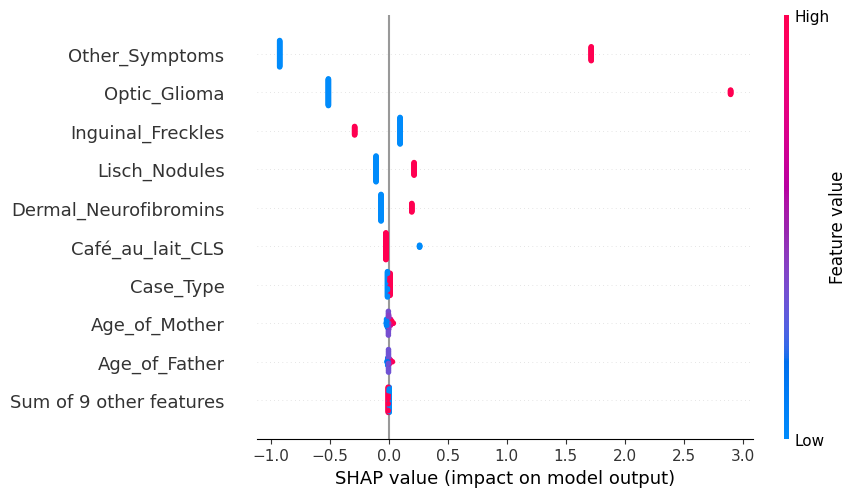

In [134]:
# SHAP PLOTS

# Beeswarm - the most informative for researchers

shap.plots.beeswarm(shap_values_lr)

In [135]:
# comment: Other Symptoms and Optic Glioma are the most significant features; height of a 'dot' indicates the number
# of samples at a given point; in Linear models, when we have  classification problem, there are ALWAYS 2 possible clusters:
#   SHAP value = w × (x - mean); suppose mean = 0.159
#       For every patient where Optic_Glioma = 0:
#       SHAP = w × (0 - 0.159) = same number for everyone
#       For every patient where Optic_Glioma = 1:
#       SHAP = w × (1 - 0.159) = same number for everyone
# also: SHAP values range here is: -1.0 to 3.0, because in LR it is just the log-odds, not the probability, so this value can extend without limit

In [136]:
shap_values_xgb

.values =
array([[ 0.        ,  0.01857959, -0.03288025, ...,  0.        ,
         0.        , -1.490742  ],
       [ 0.        ,  0.05539296,  0.09225377, ...,  0.        ,
         0.        ,  1.4435592 ],
       [ 0.        ,  0.05539296, -0.05842219, ...,  0.        ,
         0.        ,  1.4114829 ],
       ...,
       [ 0.        ,  0.01429516,  0.0558642 , ...,  0.        ,
         0.        , -1.5165758 ],
       [ 0.        ,  0.05539296, -0.05842219, ...,  0.        ,
         0.        ,  1.4114829 ],
       [ 0.        ,  0.01429516, -0.03204284, ...,  0.        ,
         0.        , -1.4916729 ]], shape=(60, 18), dtype=float32)

.base_values =
array([-0.05986504, -0.05986504, -0.05986504, -0.05986504, -0.05986504,
       -0.05986504, -0.05986504, -0.05986504, -0.05986504, -0.05986504,
       -0.05986504, -0.05986504, -0.05986504, -0.05986504, -0.05986504,
       -0.05986504, -0.05986504, -0.05986504, -0.05986504, -0.05986504,
       -0.05986504, -0.05986504, -0.059865

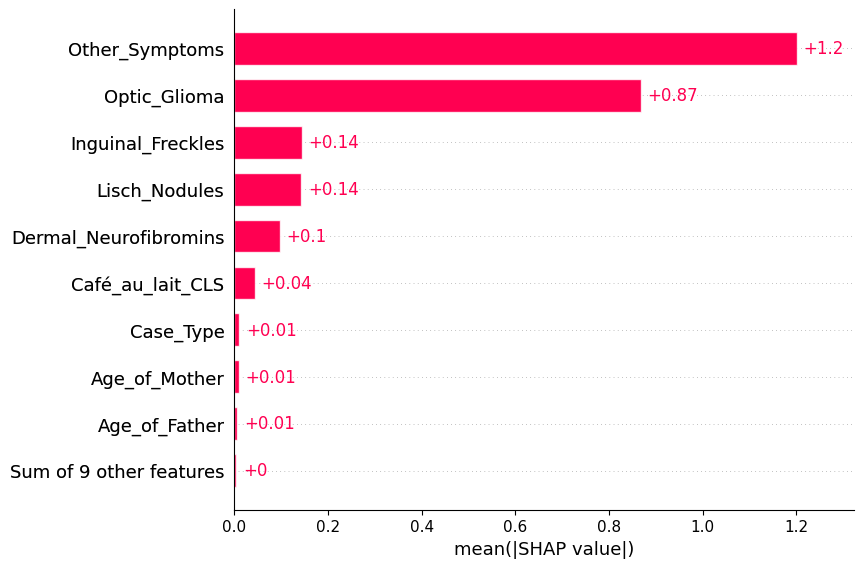

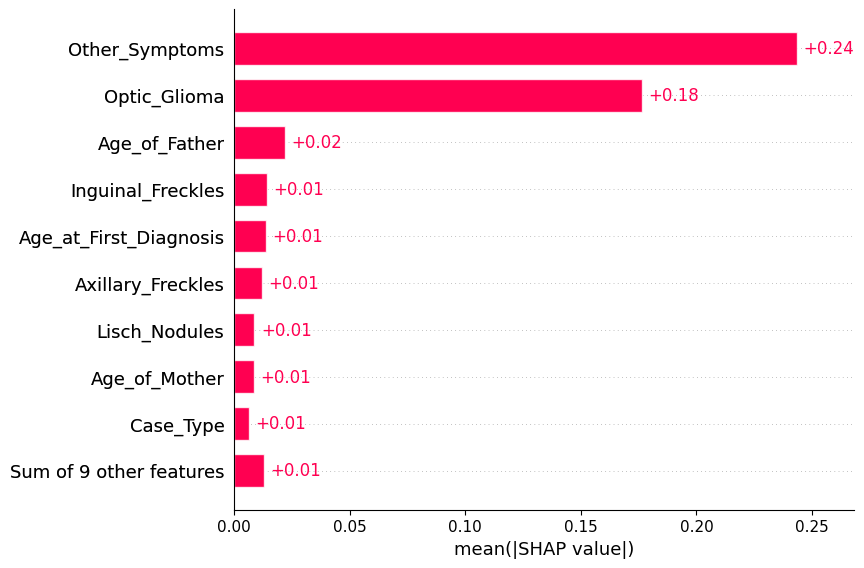

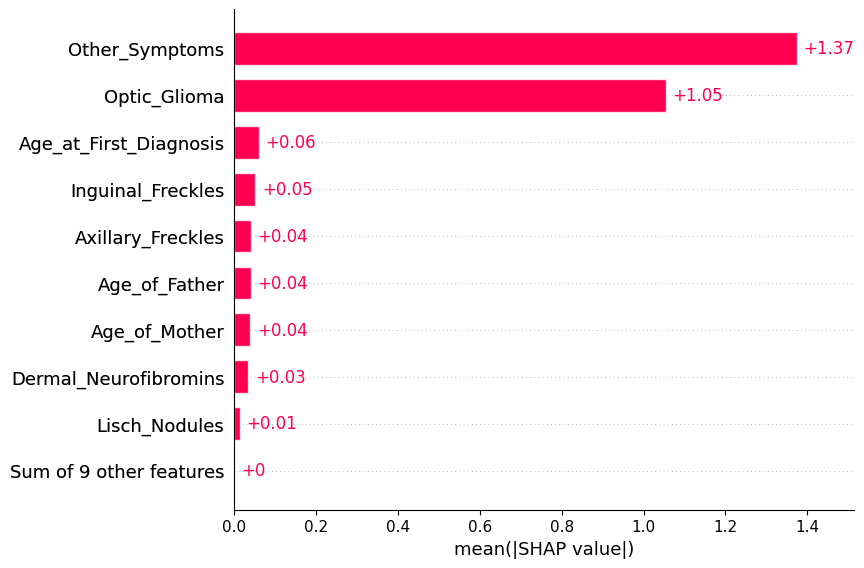

In [137]:
# another bar chart (DIFFERENT FROM feature_importances() from sklearn! - calculated in completely different way;
# it shows very clearly what impact each feature has for the prerdiction by removing them sequentially from the features
# bag)
shap.plots.bar(shap_values_lr)
shap.plots.bar(shap_values_rf[:,:,1])
shap.plots.bar(shap_values_xgb)


In [138]:
# waterfall chart 

# getting 1 sample (the problematic one in RF and XGBoost) 
explanation_pos_57 = shap_values_lr[55]

# transforming scaled data back to raw data (required for the chart), since we passed scaled values to the explainer:
#   X_te_scaled_lr = scaler_lr.transform(X_test2)
#   explainer_lr   = shap.LinearExplainer(model_lr, X_te_scaled_lr)
explanation_pos_57.data = X_test2.iloc[55].values

explanation_pos_57 # SHAP explanation data for sample #57

.values =
array([-1.02805114e-02, -2.12319247e-02, -5.79210757e-03, -0.00000000e+00,
       -2.37756472e-02,  4.41265999e-03,  9.62317850e-02, -1.07423123e-01,
       -6.50914341e-02, -0.00000000e+00, -5.11006201e-01, -0.00000000e+00,
       -0.00000000e+00, -0.00000000e+00, -1.23114731e-17,  0.00000000e+00,
       -0.00000000e+00,  1.71514020e+00])

.base_values =
np.float64(-0.638116915687661)

.data =
array([ 0., 20., 28.,  4.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  1.,  0.,  1.])

In [139]:
type(explanation_pos_57.values)

numpy.ndarray

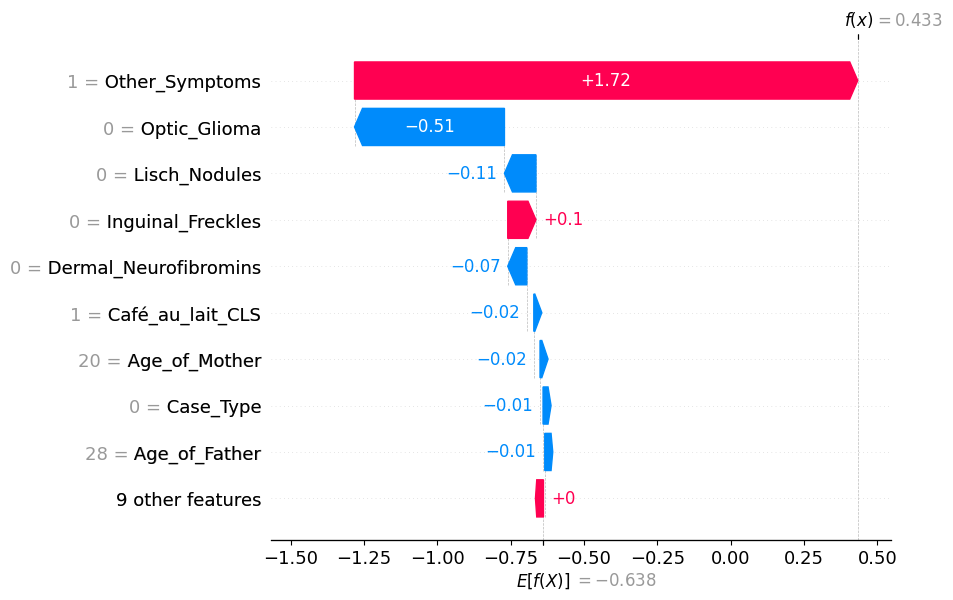

In [140]:
shap.plots.waterfall(explanation_pos_57)
# note: E[f(x)] is log-odds, not probability


In [141]:
# another example - the most confident now
conf_idx = y_prob_lr.argmax() # 29
print(f"Most confident tumour patient:")
print(X_test2.iloc[conf_idx])
print(f"Probability: {y_prob_lr[conf_idx]:.3f}")

Most confident tumour patient:
Case_Type                    0.0
Age_of_Mother               43.0
Age_of_Father               56.0
Age_at_First_Diagnosis       5.0
Café_au_lait_CLS             1.0
Axillary_Freckles            0.0
Inguinal_Freckles            0.0
Lisch_Nodules                1.0
Dermal_Neurofibromins        0.0
Plexiform_Neurofibromins     0.0
Optic_Glioma                 1.0
Skeletal_Dysplasia           0.0
Learning_Disability          0.0
Hypertension                 0.0
Astrocytoma                  0.0
Hamartoma                    0.0
Scoliosis                    0.0
Other_Symptoms               1.0
Name: 68, dtype: float64
Probability: 0.986


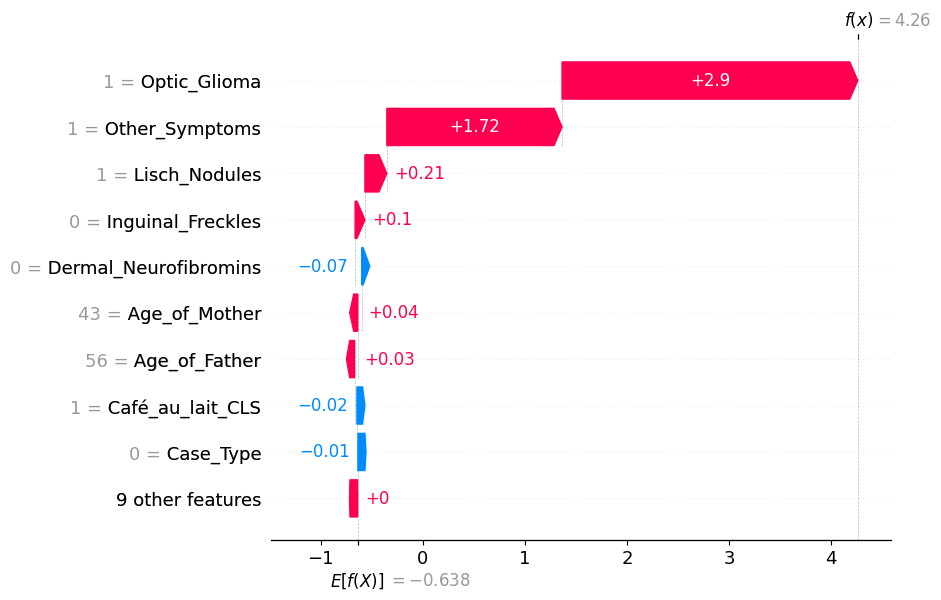

In [142]:
explanation_pos_68 = shap_values_lr[conf_idx]
# transorming scaled data back to raw data
explanation_pos_68.data = X_test2.iloc[conf_idx].values

shap.plots.waterfall(explanation_pos_68)

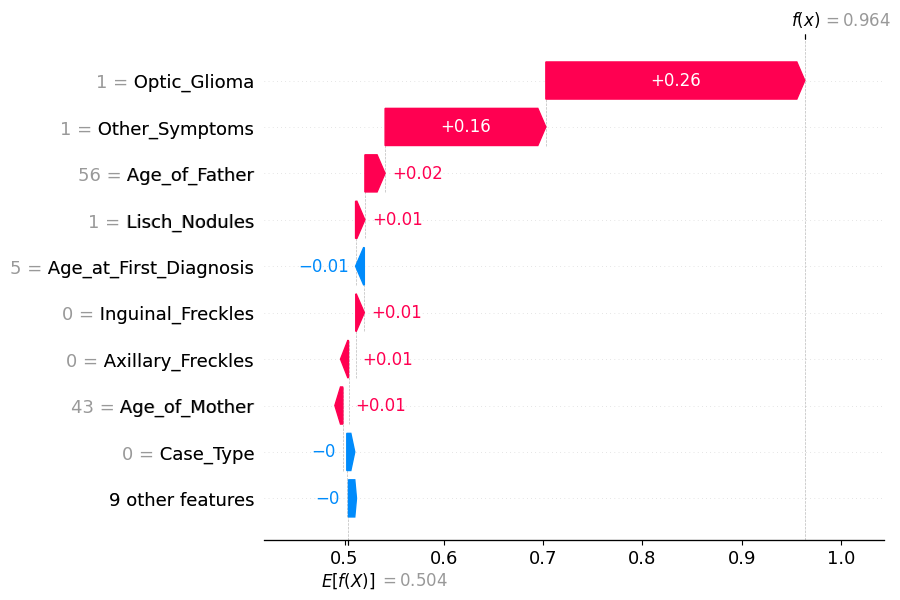

In [143]:
explanation_pos2_68 = shap_values_rf[conf_idx,:,1]
explanation_pos2_68.data = X_test2.iloc[conf_idx].values

shap.plots.waterfall(explanation_pos2_68)

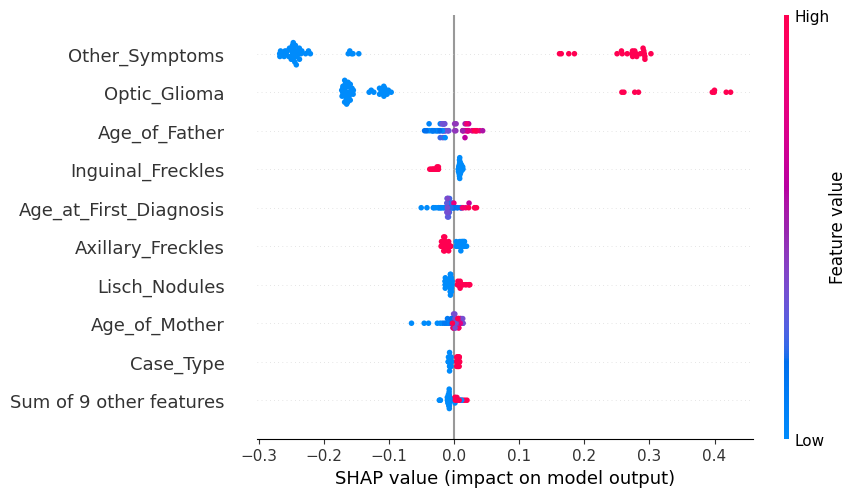

In [144]:
# Plots for RF

shap.plots.beeswarm(shap_values_rf[:,:,1])

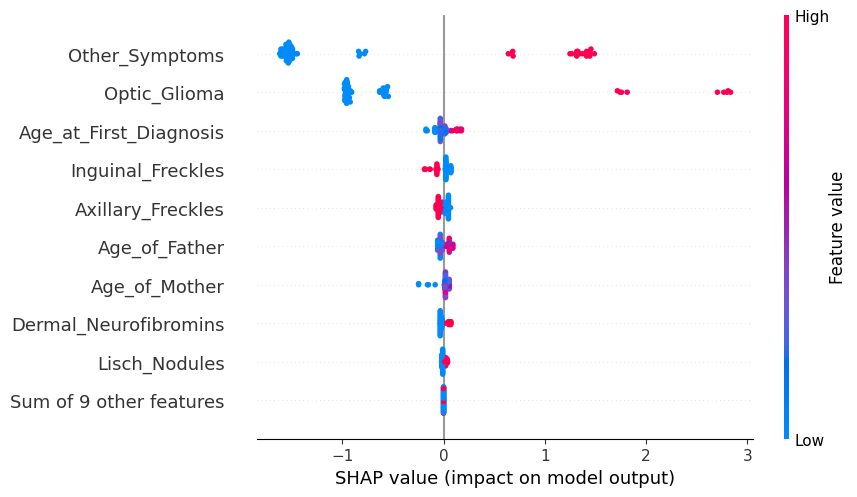

In [145]:
shap.plots.beeswarm(shap_values_xgb)

In [146]:
print("XGB baseline:", shap_values_xgb.base_values[0])
print("RF baseline:",  shap_values_rf.base_values[0][1])
print("LR baseline:",  shap_values_lr.base_values[0])

XGB baseline: -0.05986504
RF baseline: 0.503904627512988
LR baseline: -0.638116915687661


In [147]:
# probabilites from each model to plot ROC curve
y_probs = { 
    "LR": y_prob_lr, 
    "RF": y_prob_rf,
    "XGB": y_prob_xgb
}

In [148]:
from sklearn.metrics import roc_curve

def plot_roc_curves(probs, X_te, y_te):
    fig, ax = plt.subplots(figsize=(8, 6))
    colors  = ['steelblue', 'tomato', 'green']

    for (name, y_prob), color in zip(probs.items(), colors):
        fpr, tpr, _ = roc_curve(y_te, y_prob)
        auc = roc_auc_score(y_te, y_prob)
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{name} (AUC={auc:.3f})')
    ax.plot([0,1], [0,1], 'k--', label='Random baseline')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves — All Models')
    ax.legend()
    plt.tight_layout()
    return fig

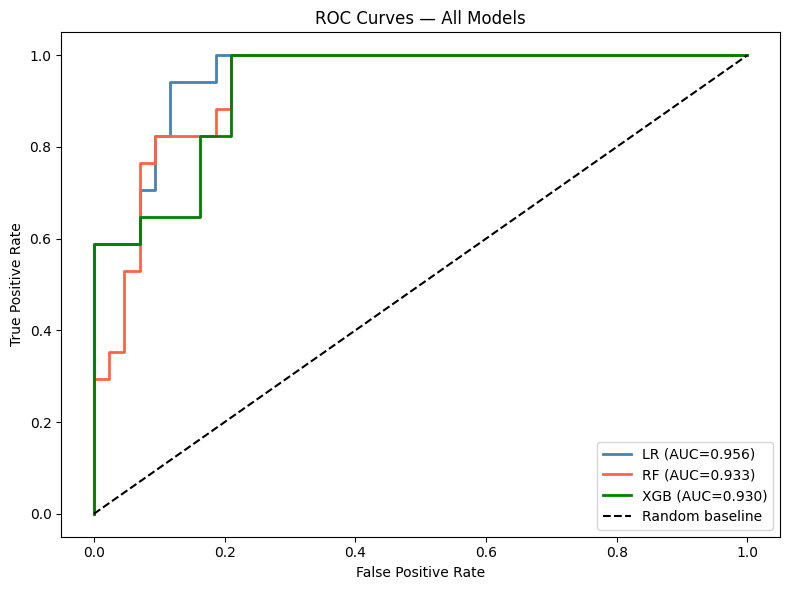

In [149]:
roc_graph = plot_roc_curves(y_probs, X_test2, y_test2)

In [ ]:
import joblib
import os


os.makedirs('../models', exist_ok=True)

# save pipelines
joblib.dump(lr_search.best_estimator_,  '../models/model_lr.pkl')
joblib.dump(rf_search.best_estimator_,  '../models/model_rf.pkl')
joblib.dump(xgb_search.best_estimator_, '../models/model_xgb.pkl')

# save scalers separately for SHAP
joblib.dump(
    lr_search.best_estimator_.named_steps['scaler'],
    '../models/scaler_lr.pkl'
)
joblib.dump(
    rf_search.best_estimator_.named_steps['scaler'],
    '../models/scaler_rf.pkl'
)
joblib.dump(
    xgb_search.best_estimator_.named_steps['scaler'],
    '../models/scaler_xgb.pkl'
)

# save data
joblib.dump(X_test2, '../models/X_te.pkl')
joblib.dump(y_test2, '../models/y_te.pkl')
joblib.dump(X_train2, '../models/X_tr.pkl')
joblib.dump(y_train2, '../models/y_tr.pkl')

# save thresholds
thresholds = {
    'lr':  thresh_lr,
    'rf':  thresh_rf,
    'xgb': thresh_xgb
}
joblib.dump(thresholds, '../models/thresholds.pkl')

# np.savez to store np arrays is more convinient
np.savez('../models/y_probs.npz',
         lr=y_prob_lr,
         rf=y_prob_rf,
         xgb=y_prob_xgb)

print("All models and data saved.")

All models and data saved.


In [151]:
# SANDBOX

In [201]:
with np.load('../backup_models/y_probs.npz') as npz:
    print(dict(npz.items()))


{'lr': array([0.10402934, 0.61195744, 0.61099372, 0.73745736, 0.13286581,
       0.09390985, 0.10243552, 0.14086851, 0.77088192, 0.10236151,
       0.65125278, 0.10085921, 0.13552317, 0.86345623, 0.98026631,
       0.67194871, 0.10175303, 0.12667412, 0.09571191, 0.9781369 ,
       0.12739869, 0.68367648, 0.10251403, 0.10127009, 0.61696032,
       0.14210382, 0.10563919, 0.744641  , 0.12902339, 0.98607249,
       0.10452682, 0.82302245, 0.67371376, 0.07052335, 0.52563714,
       0.07209703, 0.68461751, 0.65205261, 0.10046968, 0.65457897,
       0.08944097, 0.8070296 , 0.9777946 , 0.1035816 , 0.13006594,
       0.10046968, 0.09912606, 0.10418817, 0.61206034, 0.16790387,
       0.13366927, 0.13490248, 0.10328992, 0.16975241, 0.77469022,
       0.60660575, 0.61246782, 0.07221846, 0.6072189 , 0.07200594]), 'rf': array([0.09430089, 0.72381304, 0.61716421, 0.77184248, 0.09449033,
       0.07696796, 0.07114635, 0.16984118, 0.70742443, 0.06776012,
       0.66828594, 0.10364579, 0.05273234, 0.73

In [169]:
# PRE-TRAINING FILTERING (OMITTED FROM THE PROJECT, YET IMPORTANT (USED IN RESEARCH MODE))

from scipy.stats import chi2_contingency
import streamlit as st
a_cols = ['Age of Mother', 'Age of Father', 'Age at First Diagnosis']
sym_cols = [col for col in X.columns if col not in a_cols]
res_chi = []

for col in sym_cols:
    crosstab = pd.crosstab(X[col], y)
    stat, pval, dot, expect_freq = chi2_contingency(crosstab)
    chi_data = {
        'Feature name': col.replace('_', ' '),
        'Score': stat,
        'P-value': pval,
        'Exp. frequency': str(expect_freq.round(3).tolist()),
        'Is significant (p<0.5)': 'yes' if pval < 0.05 else 'no'
    }
    res_chi.append(chi_data)

result_df_chi = pd.DataFrame(res_chi).sort_values('P-value')
result_df_chi

,Feature name,Score,P-value,Exp. frequency,Is significant (p<0.5)
7,Optic Glioma,117.320127,2.442788e-27,"[[180.02, 68.98], [33.98, 13.02]]",yes
14,Other Symptoms,79.359663,5.177241e-19,"[[140.98, 54.02], [73.02, 27.98]]",yes
11,Astrocytoma,9.855143,1.693576e-03,"[[210.385, 80.615], [3.615, 1.385]]",yes
1,Café au lait (CLS),4.197399,4.048604e-02,"[[14.459, 5.541], [199.541, 76.459]]",yes
13,Scoliosis,3.375273,6.618162e-02,"[[204.601, 78.399], [9.399, 3.601]]",no
3,Inguinal Freckles,2.742006,9.774201e-02,"[[156.162, 59.838], [57.838, 22.162]]",no
8,Skeletal Dysplasia,2.734246,9.821787e-02,"[[173.514, 66.486], [40.486, 15.514]]",no
4,Lisch Nodules,2.535021,1.113454e-01,"[[153.993, 59.007], [60.007, 22.993]]",no
6,Plexiform Neurofibromins,1.395423,2.374914e-01,"[[184.358, 70.642], [29.642, 11.358]]",no
2,Axillary Freckles,1.236010,2.662414e-01,"[[99.77, 38.23], [114.23, 43.77]]",no


In [170]:
from scipy.stats import ttest_ind  
res_welch = []
for col in a_cols:
    pos_group = X[y==1][col]
    neg_group = X[y==0][col]
    score, pval = ttest_ind(
                    pos_group,
                    neg_group, 
                    equal_var=False,    # Welch's test
                    nan_policy='omit'
    )
    welch_data = {
        'Feature name': col.replace('_', ' '),
        'Score': stat,
        'P-value': pval,
        'Is significant (p<0.5)': 'yes' if pval < 0.05 else 'no'
    }
    res_welch.append(welch_data)

result_df_welch = pd.DataFrame(res_welch)

result_df_welch

,Feature name,Score,P-value,Is significant (p<0.5)
0,Age of Mother,79.359663,0.268741,no
1,Age of Father,79.359663,0.281156,no
2,Age at First Diagnosis,79.359663,0.683513,no


In [171]:
final_df = pd.concat([result_df_chi, result_df_welch])
final_df.fillna('---')

,Feature name,Score,P-value,Exp. frequency,Is significant (p<0.5)
7,Optic Glioma,117.320127,2.442788e-27,"[[180.02, 68.98], [33.98, 13.02]]",yes
14,Other Symptoms,79.359663,5.177241e-19,"[[140.98, 54.02], [73.02, 27.98]]",yes
11,Astrocytoma,9.855143,1.693576e-03,"[[210.385, 80.615], [3.615, 1.385]]",yes
1,Café au lait (CLS),4.197399,4.048604e-02,"[[14.459, 5.541], [199.541, 76.459]]",yes
13,Scoliosis,3.375273,6.618162e-02,"[[204.601, 78.399], [9.399, 3.601]]",no
3,Inguinal Freckles,2.742006,9.774201e-02,"[[156.162, 59.838], [57.838, 22.162]]",no
8,Skeletal Dysplasia,2.734246,9.821787e-02,"[[173.514, 66.486], [40.486, 15.514]]",no
4,Lisch Nodules,2.535021,1.113454e-01,"[[153.993, 59.007], [60.007, 22.993]]",no
6,Plexiform Neurofibromins,1.395423,2.374914e-01,"[[184.358, 70.642], [29.642, 11.358]]",no
2,Axillary Freckles,1.236010,2.662414e-01,"[[99.77, 38.23], [114.23, 43.77]]",no
